In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Health Insurance Dataset
df = pd.read_csv(r"C:\Users\Given\Downloads\Health Insurance Cleaned.csv", sep=";")

# Exploritory Data Analysis

In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 82 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Personal_Code                                   16000 non-null  float64
 1   Days_Visited_Two_Hospitals                      16000 non-null  int64  
 2   Months_Visited                                  16000 non-null  int64  
 3   Max_Monthly_Visit_Days                          16000 non-null  int64  
 4   Avg_Monthly_Visit_Days                          16000 non-null  float64
 5   Max_Monthly_Hospitals_Visited                   16000 non-null  int64  
 6   Avg_Monthly_Hospitals_Visited                   16000 non-null  float64
 7   Total_Visits                                    16000 non-null  int64  
 8   Max_Monthly_Visits                              16000 non-null  int64  
 9   Avg_Monthly_Visits      

<span style="font-size:22px;">The Dataset has 82 variables, of which 81 are the predictors with n = 16 000</span>

In [4]:
display(df.head())

,Personal_Code,Days_Visited_Two_Hospitals,Months_Visited,Max_Monthly_Visit_Days,Avg_Monthly_Visit_Days,Max_Monthly_Hospitals_Visited,Avg_Monthly_Hospitals_Visited,Total_Visits,Max_Monthly_Visits,Avg_Monthly_Visits,...,Drug_Cost_Percentage,Personal_Payment_Drug_Percentage,Examination_Cost_Percentage,Personal_Payment_Examination_Percentage,Treatment_Cost_Percentage,Personal_Payment_Treatment_Percentage,Civil_Affairs_Assistance,Urban_Rural_Preferential_Support,Registered,Result
0,352120000000000.00,0,6,7,5.67,3,2.17,34,7,5.67,...,0.94,0.00,0.05,0.00,0.01,0.00,0,0,1,0
1,352120000000000.00,0,6,4,2.50,2,1.33,15,4,2.50,...,0.96,0.00,0.03,0.00,0.01,0.00,0,0,1,0
2,352120000000000.00,8,6,8,6.17,3,2.17,45,9,7.50,...,0.78,0.00,0.00,0.00,0.20,0.00,0,0,0,0
3,352120000000000.00,0,6,6,3.67,2,1.83,23,6,3.83,...,0.46,0.00,0.00,0.00,0.54,0.00,0,0,0,0
4,352120000000000.00,0,6,5,4.33,1,1.00,26,5,4.33,...,0.98,0.00,0.00,0.00,0.02,0.00,0,0,0,0


## 1. Checking for Multicolinearinty

Expanded correlation matrix plot has been generated and saved as 'correlation_matrix_expanded.png'


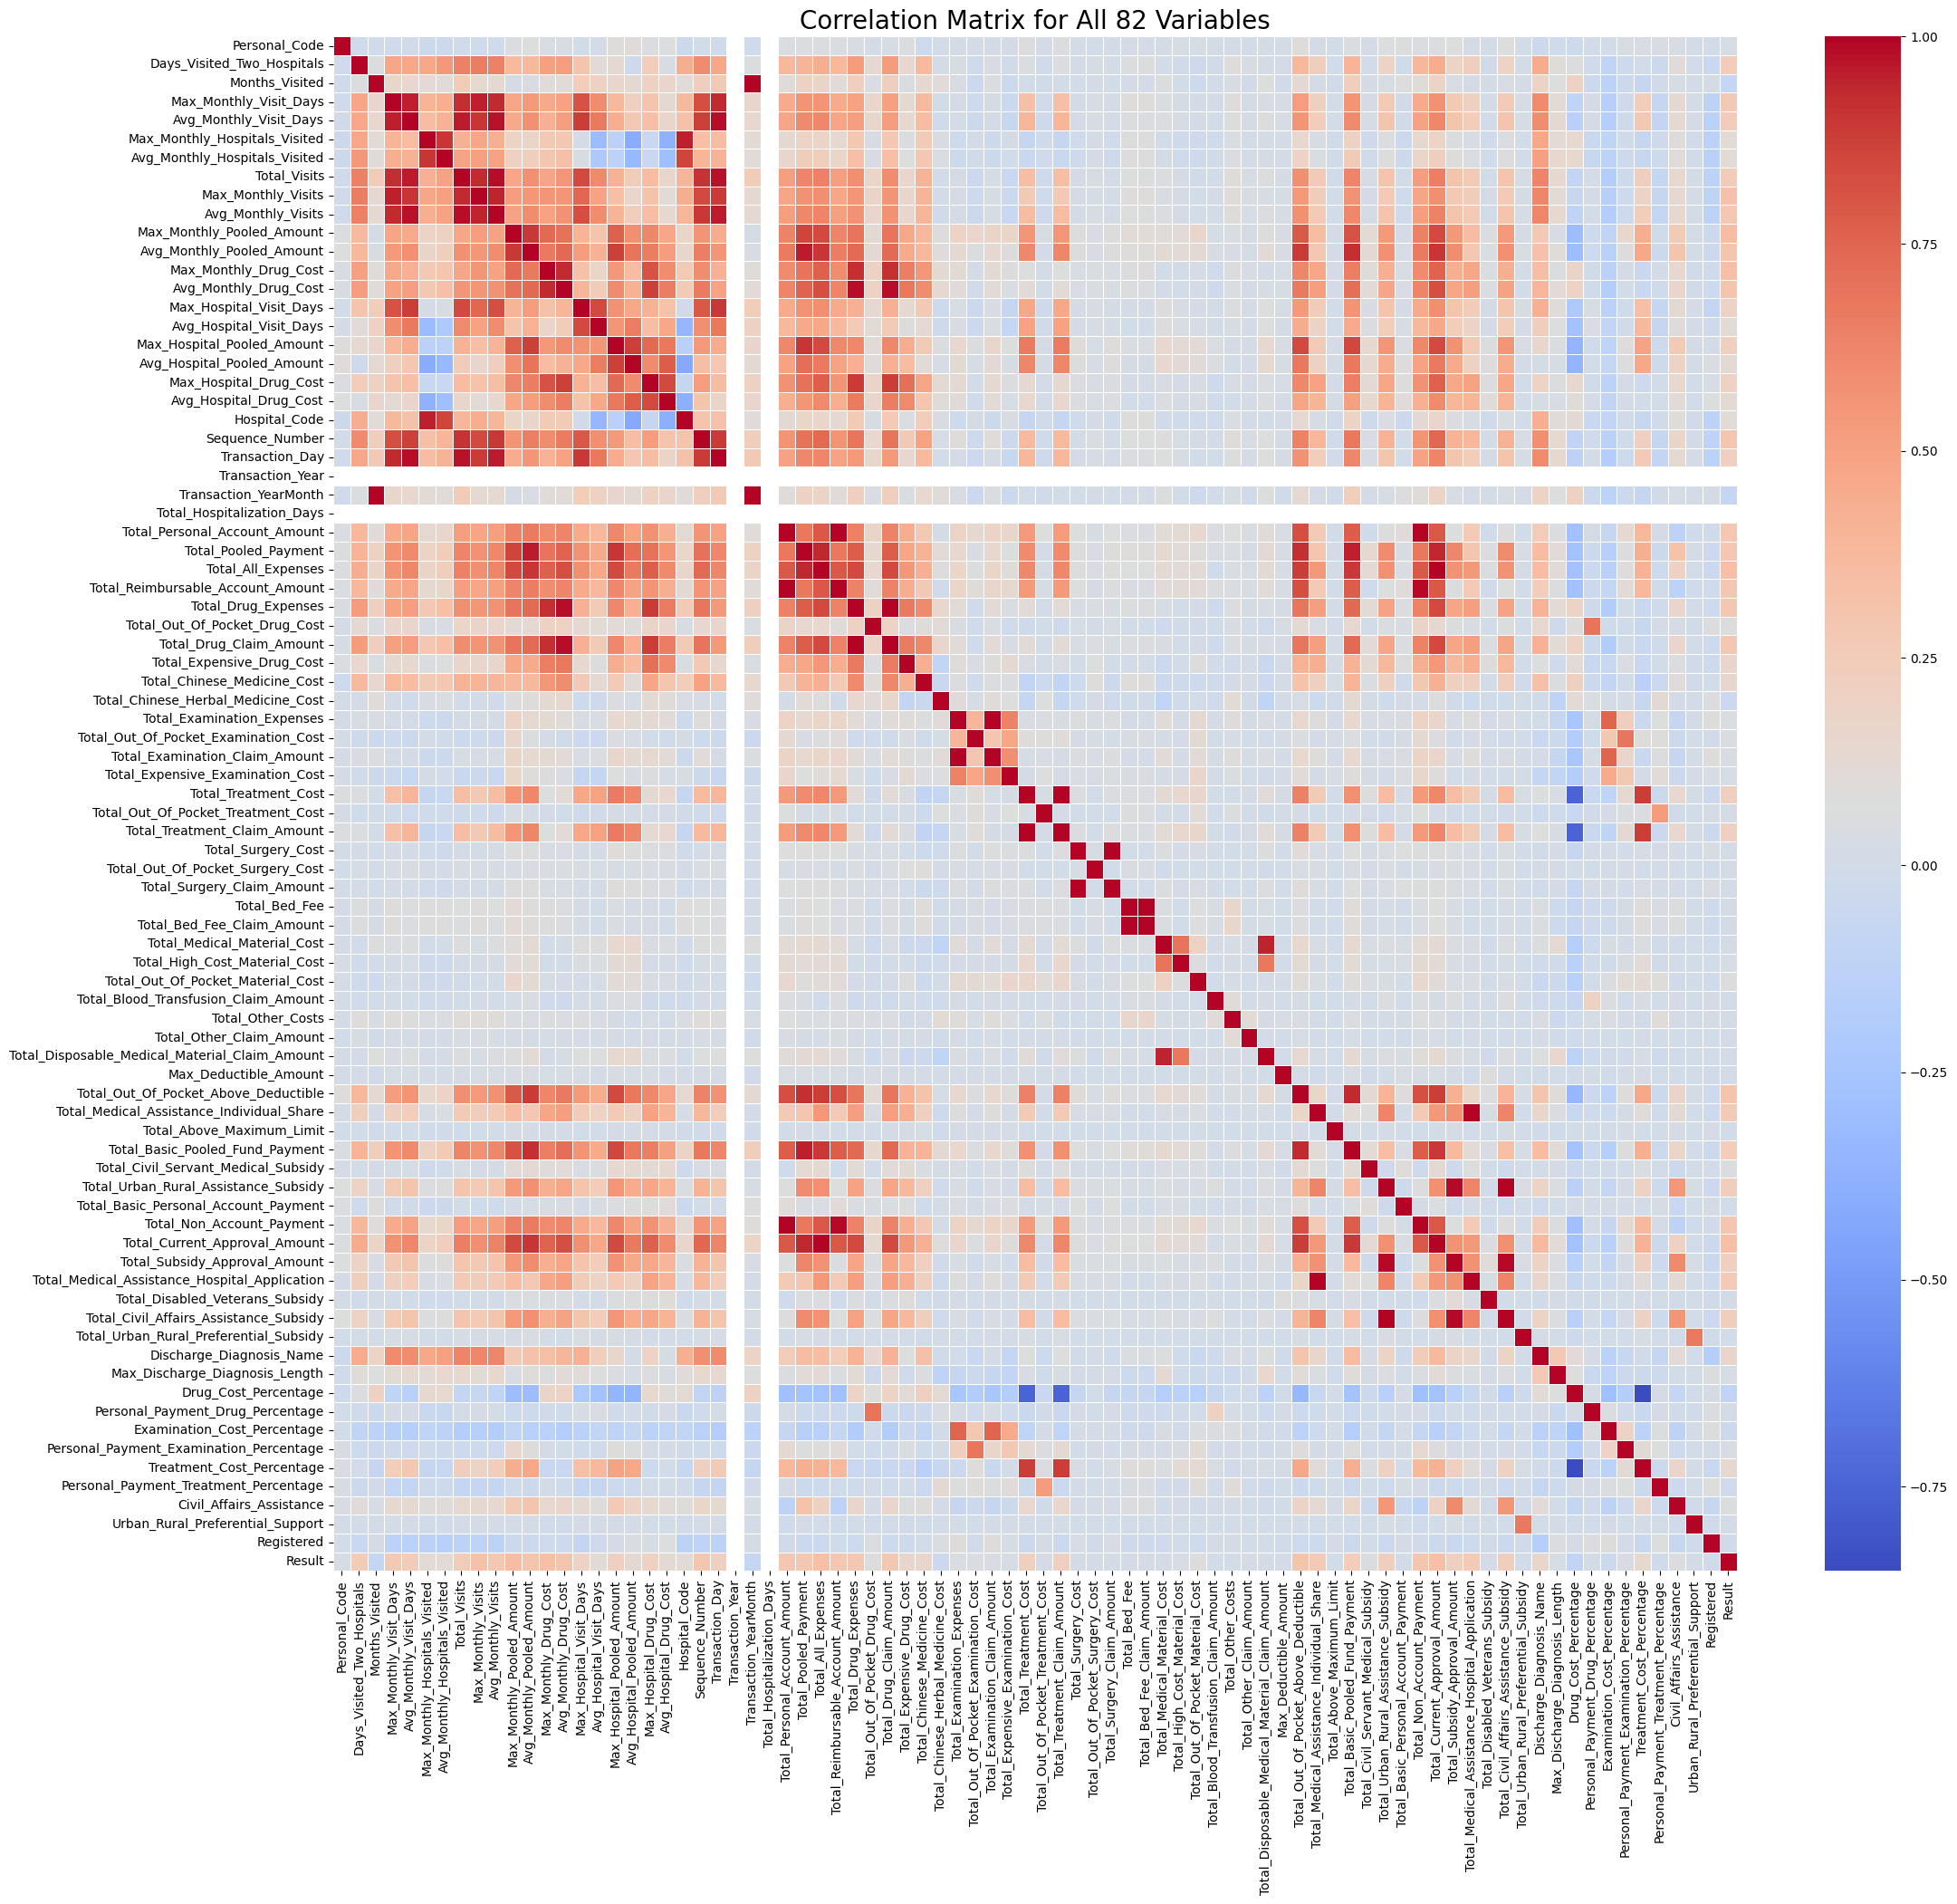

In [5]:
# The correlation matrix
correlation_matrix = df.corr()


plt.figure(figsize=(25, 22))


sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=.5
)

plt.title("Correlation Matrix for All 82 Variables", fontsize=20)
plt.xticks(rotation=90)
plt.savefig("correlation_matrix_expanded.png", dpi=150)
print("Expanded correlation matrix plot has been generated and saved as 'correlation_matrix_expanded.png'")

### 1.1. Checking for correlation with a threshold of |r|>0.75

In [6]:
corr_matrix = df.corr().abs()
high_corr_vars = [(i, j, corr_matrix.loc[i, j]) 
                  for i in corr_matrix.columns 
                  for j in corr_matrix.columns 
                  if i != j and corr_matrix.loc[i, j] > 0.75]

print("\nHighly Correlated Variables (Threshold > 0.75):")
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    print(f"{var1} - {var2}: {corr:.2f}")


Highly Correlated Variables (Threshold > 0.75):
Months_Visited - Transaction_YearMonth: 1.00
Transaction_YearMonth - Months_Visited: 1.00
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00
Total_Medical_Assistance_Hospital_Application - Total_Medical_Assistance_Individual_Share: 1.00
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00
Total_Treatment_Claim_Amount - Total_Treatment_Cost: 1.00
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00
Total_Drug_Claim_Amount - Total_Drug_Expenses: 1.00
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00
Total_Bed_Fee_Claim_Amount - Total_Bed_Fee: 1.00
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00
Total_Surgery_Claim_Amount - Total_Surgery_Cost: 1.00
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00
Total_Civil_Affairs_Assistance_Subsidy - Total_Urban_Rural_Assistance_Subsidy: 1.00
Total_All_Expenses - Total_Current_Approval_Amount: 1.00
Total_Current_Appr

## 2. Removing one variable from each highly correlated pair

In [7]:
removed_features = set()
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    if var1 not in removed_features and var2 not in removed_features:
        print(f"{var1} - {var2}: {corr:.2f} (Removing {var2})")
        removed_features.add(var2)
df.drop(columns=removed_features, inplace=True)

Months_Visited - Transaction_YearMonth: 1.00 (Removing Transaction_YearMonth)
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00 (Removing Total_Medical_Assistance_Hospital_Application)
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00 (Removing Total_Treatment_Claim_Amount)
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00 (Removing Total_Drug_Claim_Amount)
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00 (Removing Total_Bed_Fee_Claim_Amount)
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00 (Removing Total_Surgery_Claim_Amount)
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00 (Removing Total_Civil_Affairs_Assistance_Subsidy)
Total_All_Expenses - Total_Current_Approval_Amount: 1.00 (Removing Total_Current_Approval_Amount)
Total_Personal_Account_Amount - Total_Non_Account_Payment: 1.00 (Removing Total_Non_Account_Payment)
Total_Examination_Expenses - Total_Examination_Claim_Amount: 0.99 (Remov

In [8]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Personal_Code                              16000 non-null  float64
 1   Days_Visited_Two_Hospitals                 16000 non-null  int64  
 2   Months_Visited                             16000 non-null  int64  
 3   Max_Monthly_Visit_Days                     16000 non-null  int64  
 4   Max_Monthly_Hospitals_Visited              16000 non-null  int64  
 5   Max_Monthly_Pooled_Amount                  16000 non-null  float64
 6   Max_Monthly_Drug_Cost                      16000 non-null  float64
 7   Transaction_Year                           16000 non-null  int64  
 8   Total_Hospitalization_Days                 16000 non-null  int64  
 9   Total_Personal_Account_Amount              16000 non-null  float64
 10  Total_O

<span style="font-size:18px;">After removing variables with high multicolinearity, we now have 46 variables, of which 45 are the predictors</span>

## 3. Checking the Dataset for missing values

In [9]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Personal_Code                                 0
Days_Visited_Two_Hospitals                    0
Months_Visited                                0
Max_Monthly_Visit_Days                        0
Max_Monthly_Hospitals_Visited                 0
Max_Monthly_Pooled_Amount                     0
Max_Monthly_Drug_Cost                         0
Transaction_Year                              0
Total_Hospitalization_Days                    0
Total_Personal_Account_Amount                 0
Total_Out_Of_Pocket_Drug_Cost                 0
Total_Expensive_Drug_Cost                     0
Total_Chinese_Medicine_Cost                   0
Total_Chinese_Herbal_Medicine_Cost            0
Total_Examination_Expenses                    0
Total_Out_Of_Pocket_Examination_Cost          0
Total_Expensive_Examination_Cost              0
Total_Treatment_Cost                          0
Total_Out_Of_Pocket_Treatment_Cost            0
Total_Surgery_Cost                            0
Total_Out_Of_Pocket_Sur

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage has 24 missing values</span>

## 4. Dealing with missing Values

In [10]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Personal_Code                                0
Days_Visited_Two_Hospitals                   0
Months_Visited                               0
Max_Monthly_Visit_Days                       0
Max_Monthly_Hospitals_Visited                0
Max_Monthly_Pooled_Amount                    0
Max_Monthly_Drug_Cost                        0
Transaction_Year                             0
Total_Hospitalization_Days                   0
Total_Personal_Account_Amount                0
Total_Out_Of_Pocket_Drug_Cost                0
Total_Expensive_Drug_Cost                    0
Total_Chinese_Medicine_Cost                  0
Total_Chinese_Herbal_Medicine_Cost           0
Total_Examination_Expenses                   0
Total_Out_Of_Pocket_Examination_Cost         0
Total_Expensive_Examination_Cost             0
Total_Treatment_Cost                         0
Total_Out_Of_Pocket_Treatment_Cost           0
Total_Surgery_Cost                           0
Total_Out_Of_Pocket_Surgery_

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage now has 0 missing values</span>

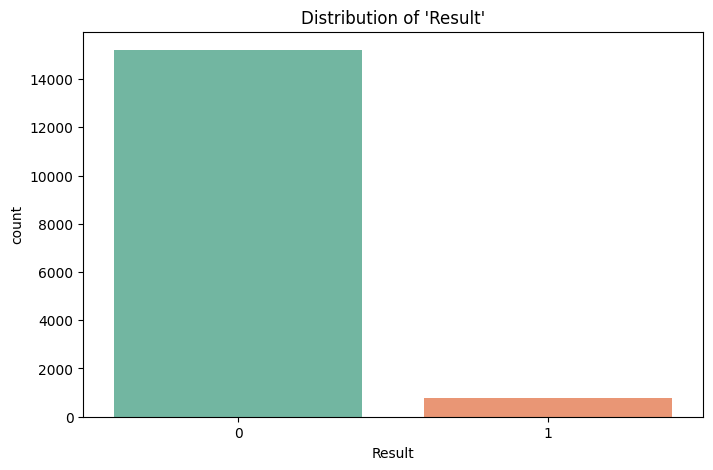

In [11]:
## 5. Cheking the imbalance of the response variable 'Result'

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Result', hue='Result', palette='Set2', legend=False)

plt.title("Distribution of 'Result'")
plt.show()

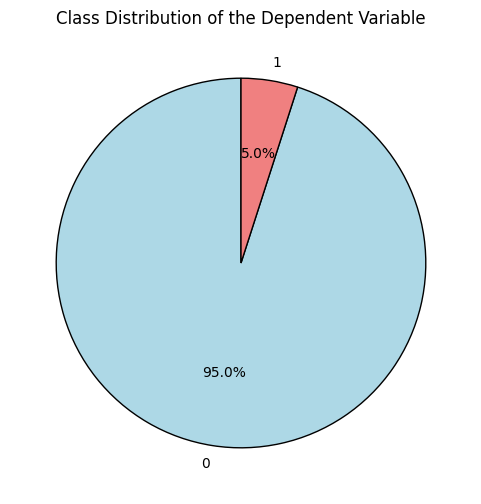


Class Counts:
Result
0    15207
1      793
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(6, 6))
df['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution of the Dependent Variable")
plt.ylabel("")
plt.show()

print("\nClass Counts:")
print(df['Result'].value_counts())

<span style="font-size:20px;">The target variable 'Result' is highly imbalanced</span>

## 6. Checking for outliers using Boxplots

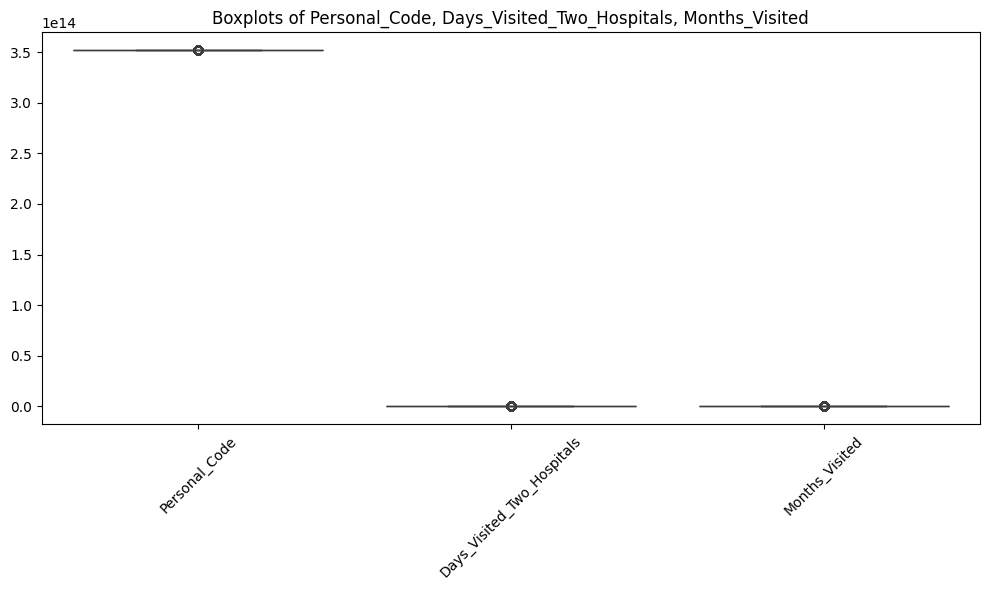

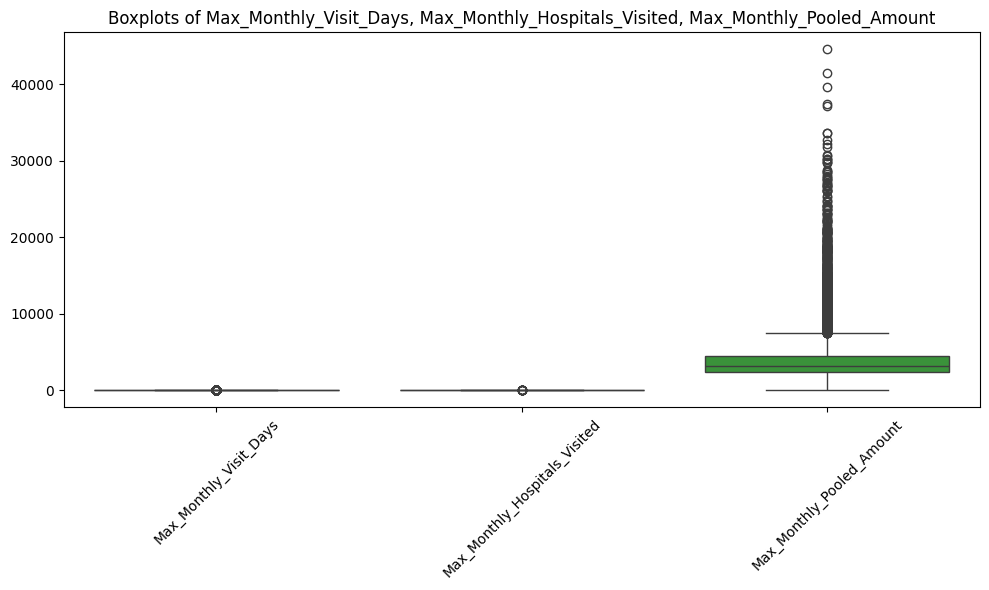

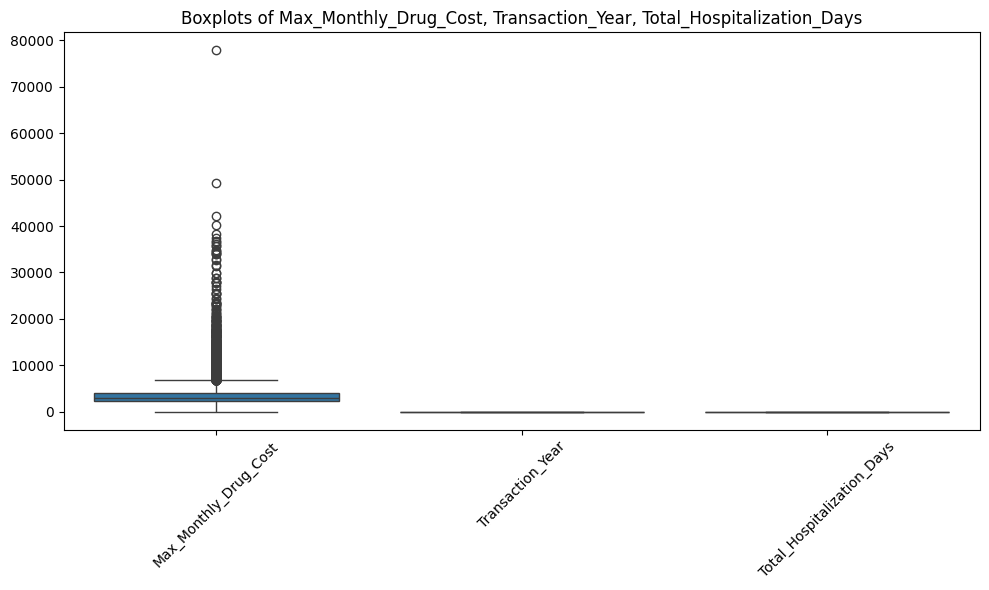

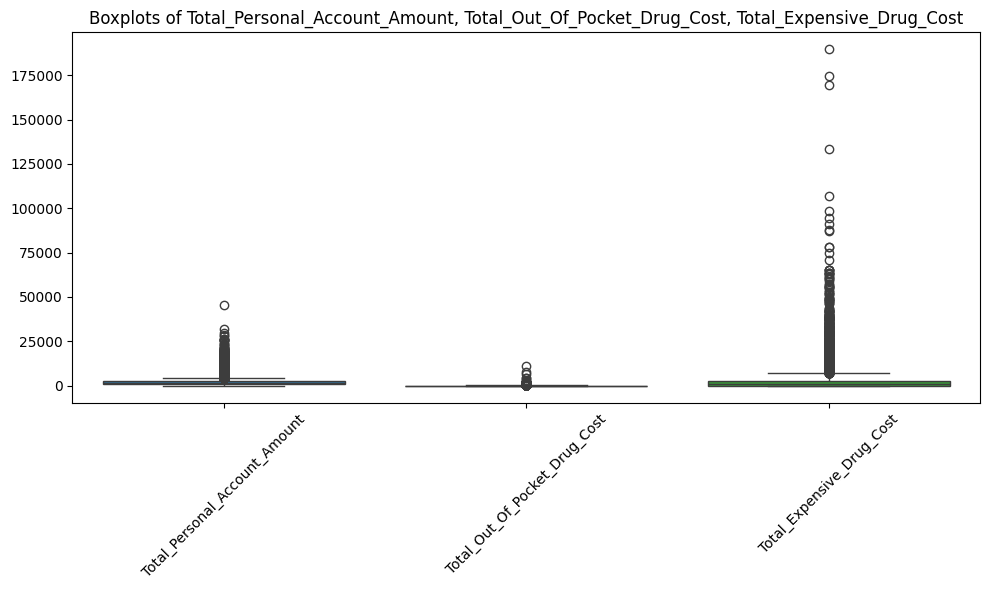

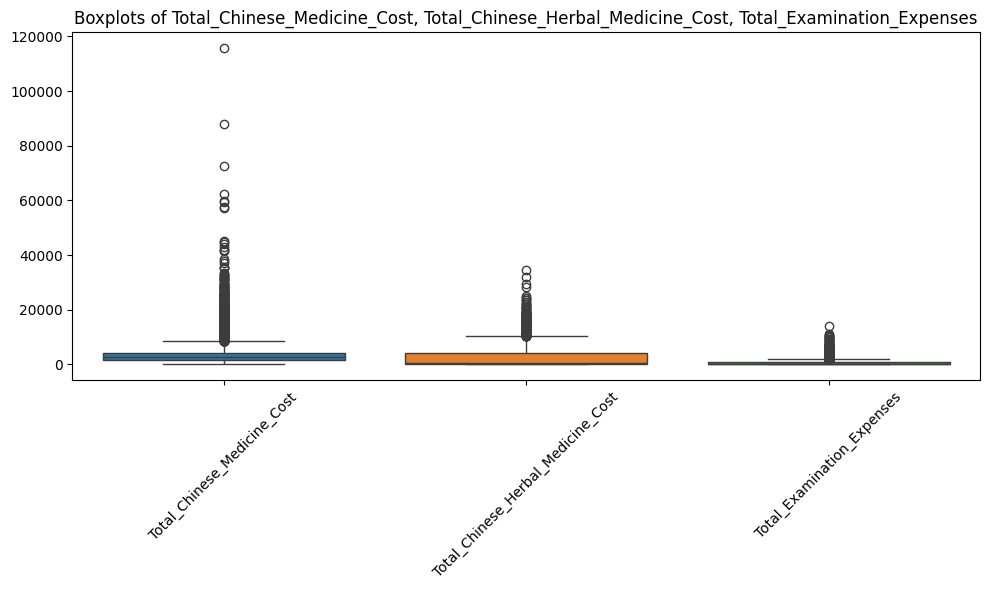

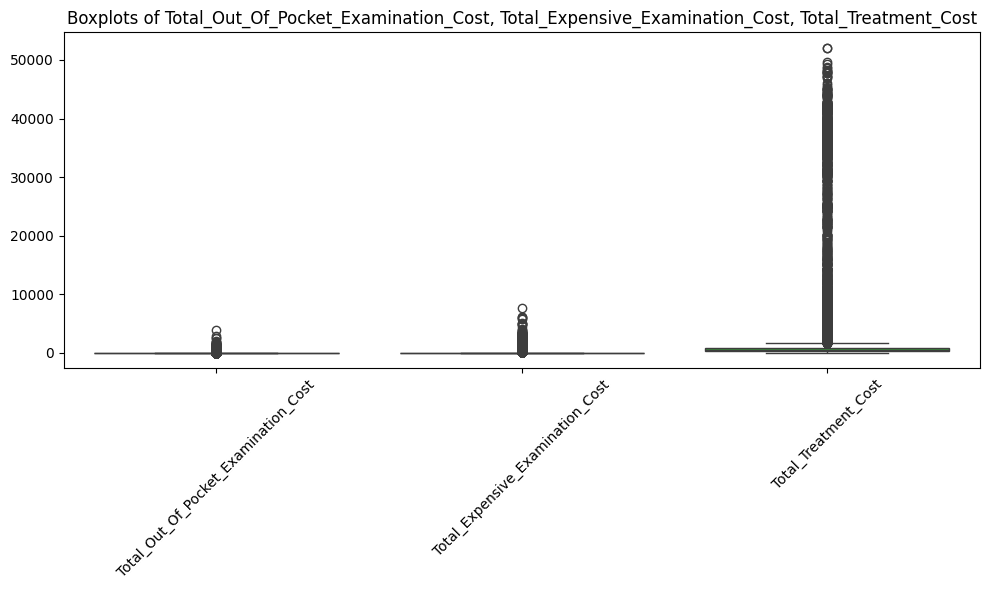

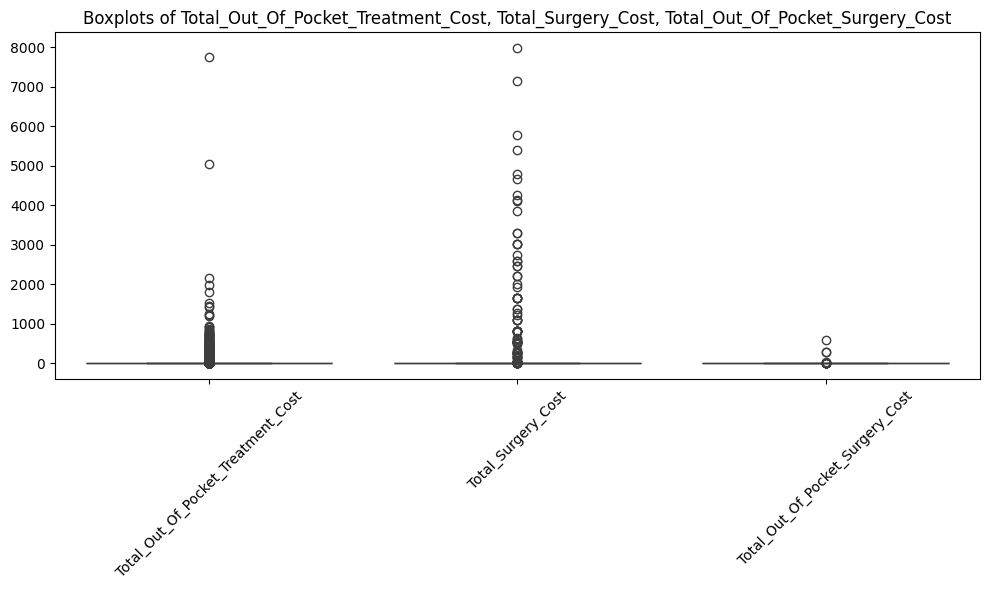

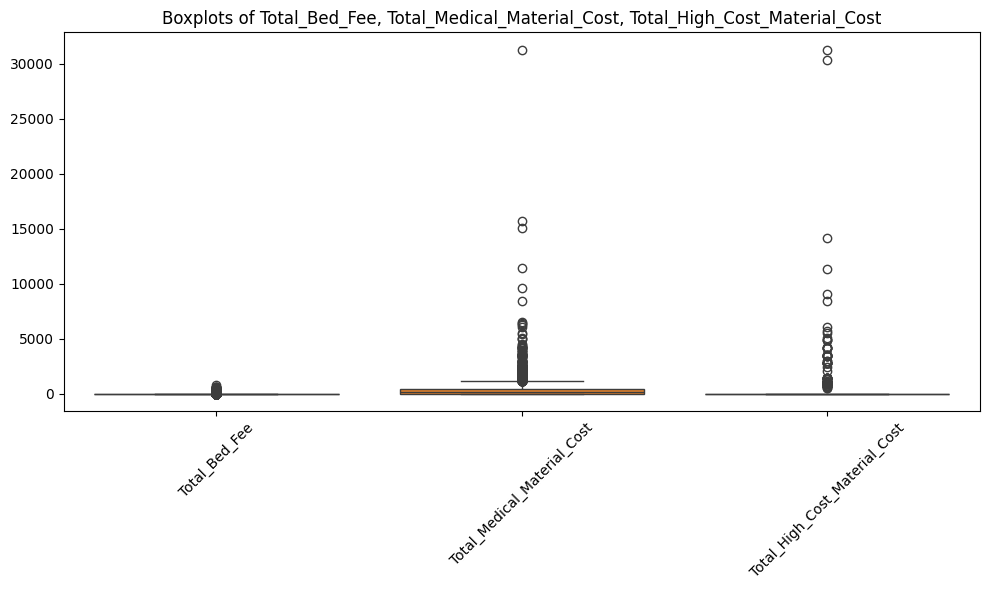

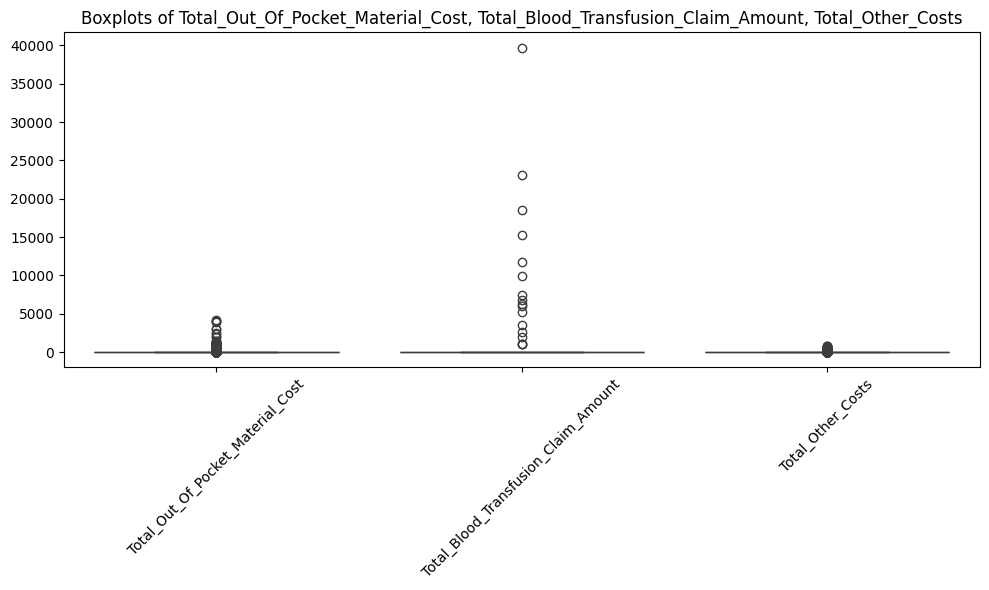

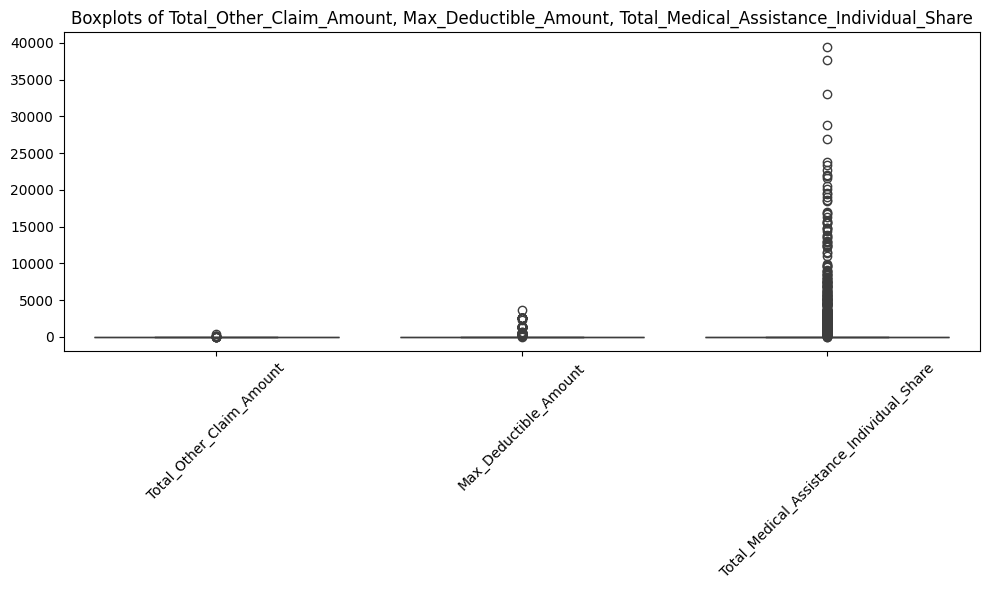

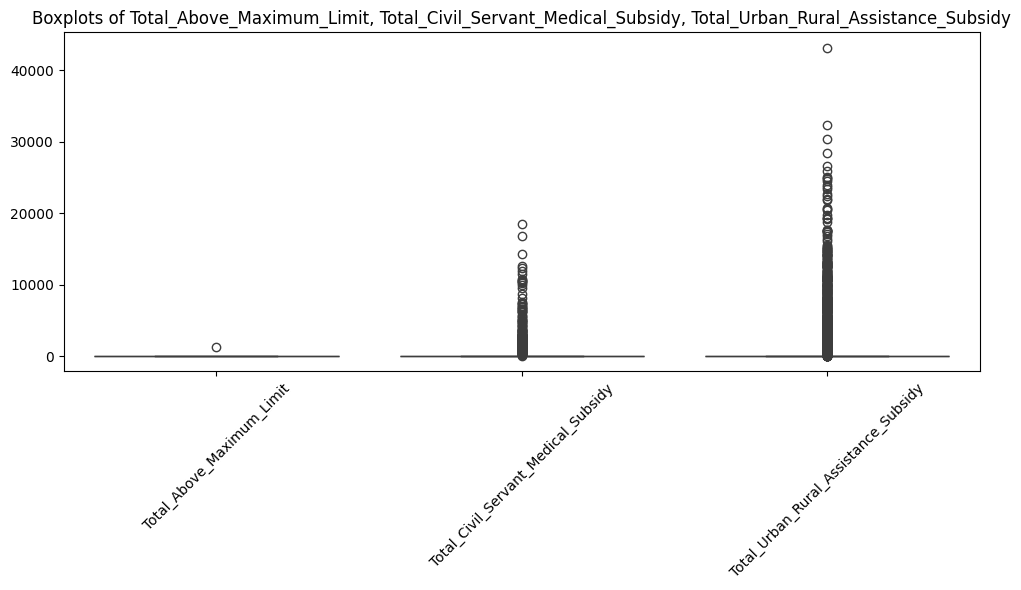

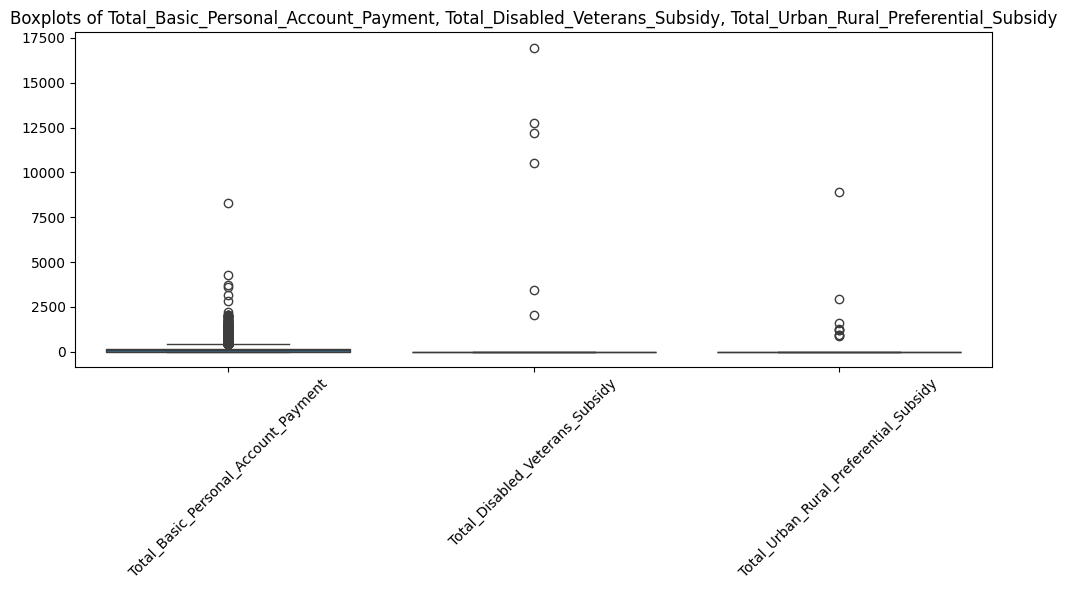

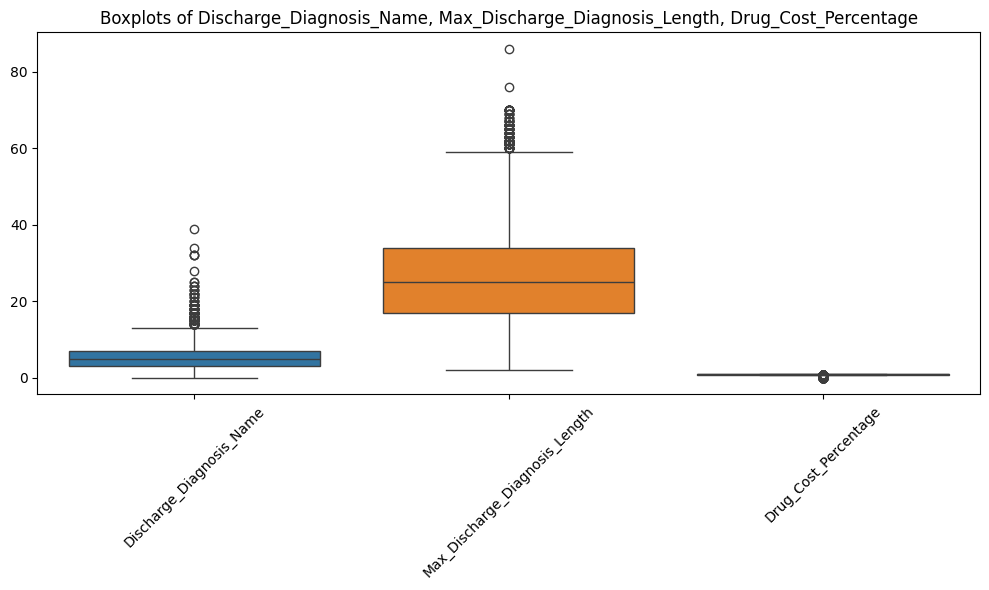

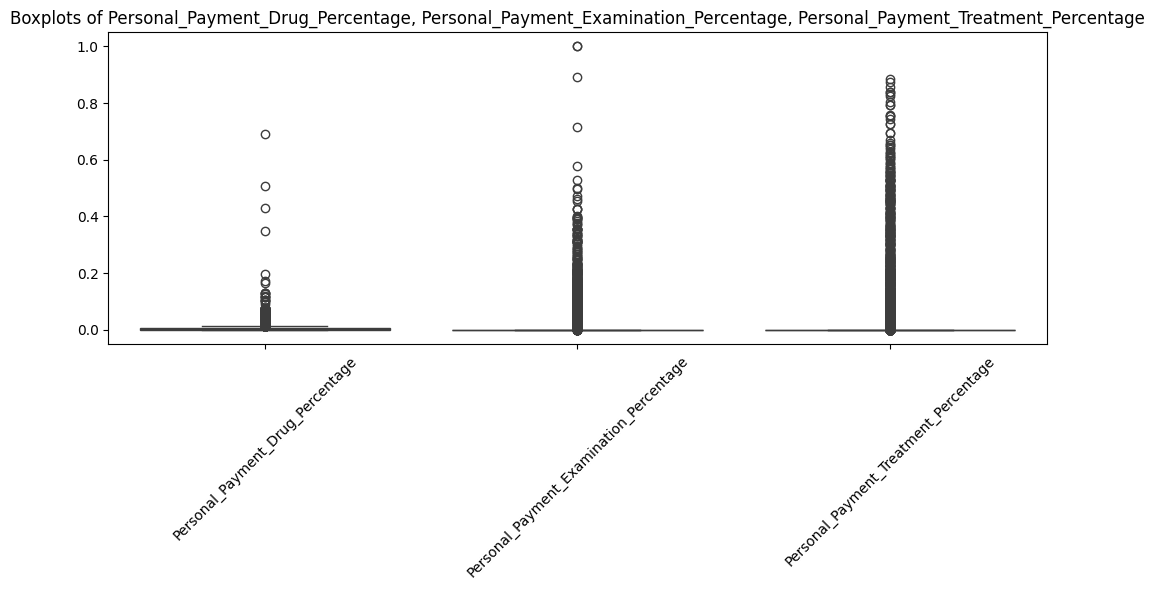

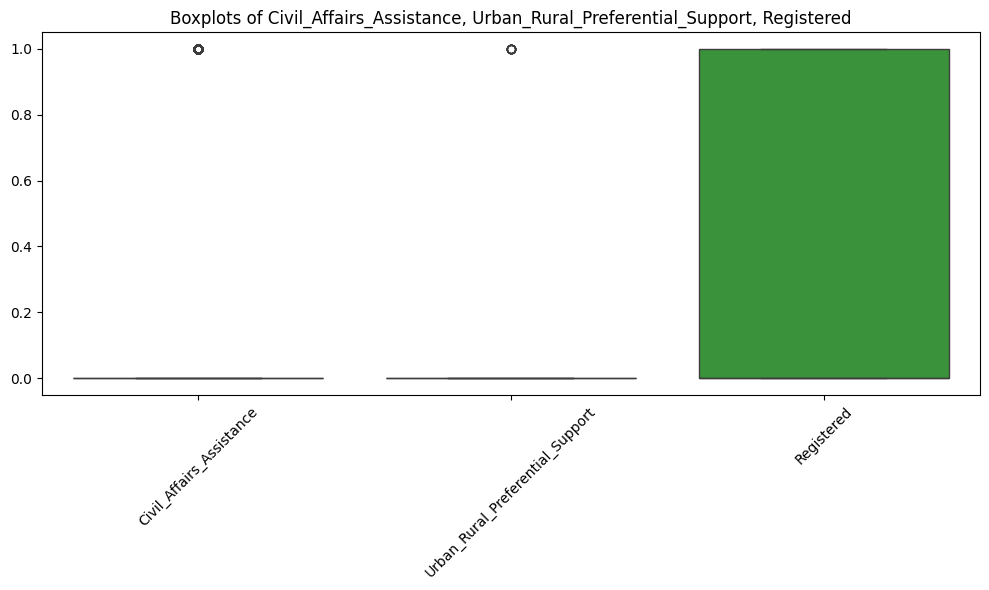

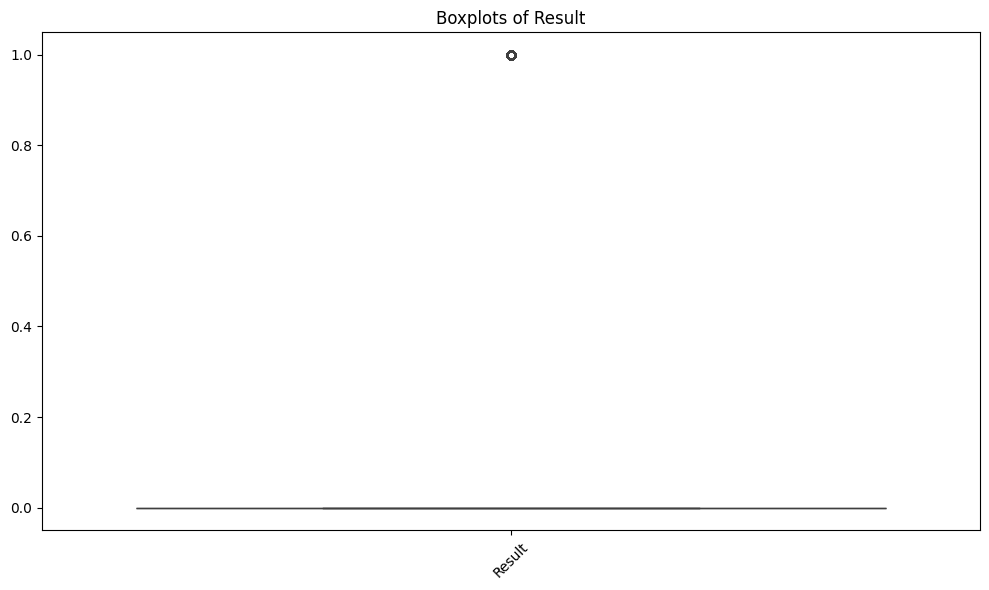

In [13]:
num_cols = df.select_dtypes(include=np.number).columns
vars_per_plot = 3

# Plot boxplots in groups
for i in range(0, len(num_cols), vars_per_plot):
    cols_to_plot = num_cols[i:i + vars_per_plot]
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[cols_to_plot])
    plt.title(f'Boxplots of {", ".join(cols_to_plot)}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<span style="font-size:18px;">The is a presence of outliers in most of the variables</span>

# Model Picking - Lazy Predict

## 1. Lazy Predict

In [14]:
X, y = df.drop(columns=['Result']), df['Result']

In [15]:
feature_names = X.columns

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = StandardScaler().fit_transform(X_train), StandardScaler().fit_transform(X_test)

In [17]:
models, _ = LazyClassifier(verbose=0, ignore_warnings=True).fit(X_train, X_test, y_train, y_test)
print(models)

  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 97%|███████████████████████████████████████████████████████████████████████████████▍  | 31/32 [02:39<00:02,  2.38s/it]

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5688
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [02:42<00:00,  5.06s/it]


                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.90               0.73     0.73      0.92   
DecisionTreeClassifier             0.94               0.73     0.73      0.94   
LinearDiscriminantAnalysis         0.96               0.71     0.71      0.95   
BaggingClassifier                  0.96               0.70     0.70      0.96   
Perceptron                         0.91               0.69     0.69      0.92   
XGBClassifier                      0.96               0.68     0.68      0.96   
LGBMClassifier                     0.96               0.68     0.68      0.96   
BernoulliNB                        0.57               0.67     0.67      0.69   
RandomForestClassifier             0.97               0.67     0.67      0.96   
SGDClassifier                      0.95               0.66     0.66      0.95   
ExtraTreeClassifier         

## Models To be used
1. **NearestCentroid**
2. **DecisionTreeClassifier**
3. **LinearDiscriminantAnalysis**
4. **BaggingClassifier** 
5. **Perceptron**
6. **XGBClassifier**
7. **LGBMClassifier**
8. **BernoulliNB** 
9. **RandomForestClassifier**
10. **SGDClassifier**
11. **ExtraTreesClassifier**

# Modelling

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import Perceptron
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import ExtraTreeClassifier

## Recursive Feature Elimination (RFE)

In [19]:
# Applying RFE
estimator = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selector = RFECV(estimator=estimator, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
selector.fit(X_train, y_train)

print("Optimal number of features selected:", selector.n_features_)

Optimal number of features selected: 20


In [20]:
selected_features = np.array(feature_names)[selector.support_]
print("Selected features:")
print(selected_features.tolist())

Selected features:
['Days_Visited_Two_Hospitals', 'Months_Visited', 'Max_Monthly_Visit_Days', 'Max_Monthly_Pooled_Amount', 'Max_Monthly_Drug_Cost', 'Total_Personal_Account_Amount', 'Total_Out_Of_Pocket_Drug_Cost', 'Total_Expensive_Drug_Cost', 'Total_Chinese_Medicine_Cost', 'Total_Chinese_Herbal_Medicine_Cost', 'Total_Examination_Expenses', 'Total_Treatment_Cost', 'Total_Medical_Material_Cost', 'Total_Medical_Assistance_Individual_Share', 'Total_Urban_Rural_Assistance_Subsidy', 'Total_Basic_Personal_Account_Payment', 'Discharge_Diagnosis_Name', 'Max_Discharge_Diagnosis_Length', 'Drug_Cost_Percentage', 'Personal_Payment_Drug_Percentage']


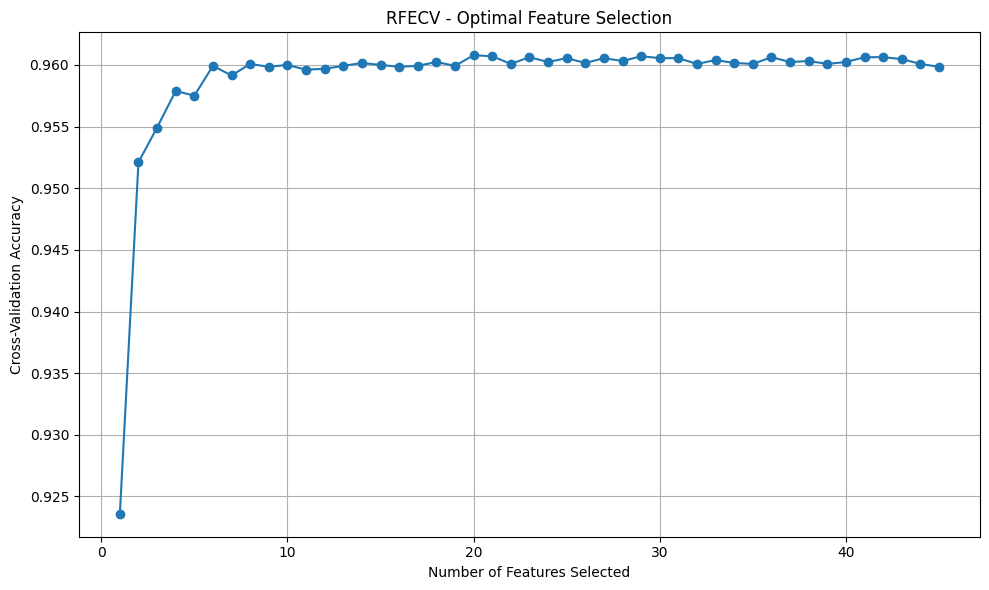

In [21]:
# Plot performance vs number of features
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RFECV - Optimal Feature Selection")
plt.grid(True)
plt.tight_layout()
plt.show()


Feature importances:
Max_Monthly_Pooled_Amount                   0.13
Max_Monthly_Drug_Cost                       0.10
Total_Personal_Account_Amount               0.08
Max_Monthly_Visit_Days                      0.07
Total_Treatment_Cost                        0.06
Drug_Cost_Percentage                        0.06
Total_Chinese_Medicine_Cost                 0.05
Total_Out_Of_Pocket_Drug_Cost               0.05
Total_Examination_Expenses                  0.04
Personal_Payment_Drug_Percentage            0.04
Total_Medical_Material_Cost                 0.04
Max_Discharge_Diagnosis_Length              0.04
Total_Expensive_Drug_Cost                   0.04
Discharge_Diagnosis_Name                    0.04
Total_Basic_Personal_Account_Payment        0.03
Total_Chinese_Herbal_Medicine_Cost          0.03
Total_Medical_Assistance_Individual_Share   0.03
Days_Visited_Two_Hospitals                  0.03
Total_Urban_Rural_Assistance_Subsidy        0.03
Months_Visited                              0.0

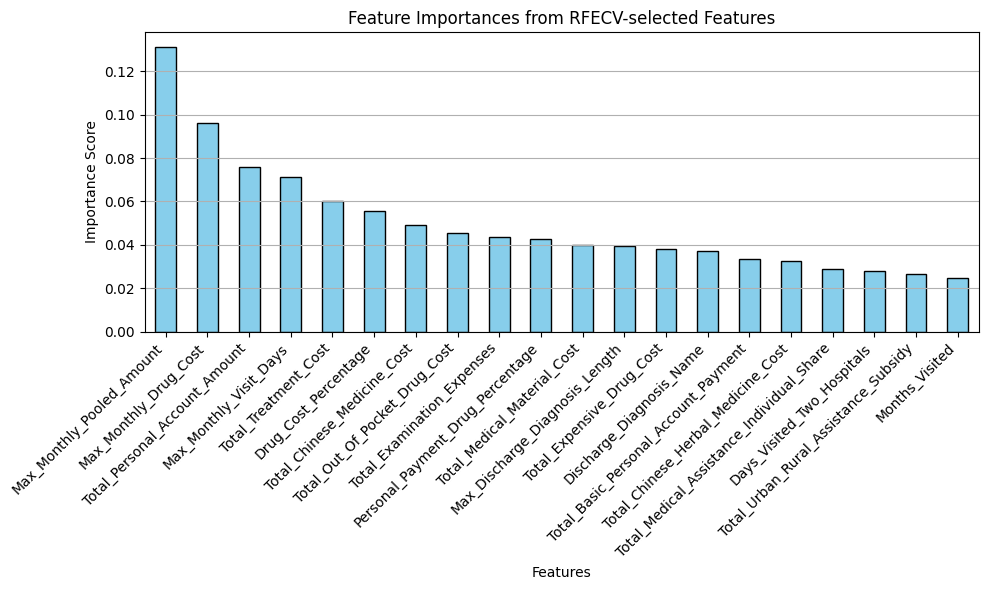

In [22]:
feature_importances = selector.estimator_.feature_importances_
important_features = pd.Series(feature_importances, index=selected_features)
important_features = important_features.sort_values(ascending=False)

print("\nFeature importances:")
print(important_features)


# Plot feature importances
plt.figure(figsize=(10, 6))
important_features.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Feature Importances from RFECV-selected Features")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [23]:
# Transform train and test sets based on selected features
X_train_rfe = selector.transform(X_train)
X_test_rfe = selector.transform(X_test)
y_train_rfe = y_train
y_test_rfe = y_test

## 1. Nearest Centroid

In [24]:
# Initialize and train Model
nc = NearestCentroid()
nc.fit(X_train_rfe, y_train_rfe)

NearestCentroid()

In [25]:
# Make predictions
y_pred_NC = nc.predict(X_test_rfe)

In [26]:
# Evaluating the model
accuracy_NC = accuracy_score(y_test_rfe, y_pred_NC)
conf_matrix_NC = confusion_matrix(y_test_rfe, y_pred_NC)
class_report_NC = classification_report(y_test_rfe, y_pred_NC)

TP = conf_matrix_NC[1, 1]
FN = conf_matrix_NC[1, 0]
FP = conf_matrix_NC[0, 1]
TN = conf_matrix_NC[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_NC:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_NC)

Evaluation Metrics:
Accuracy: 0.9022
True Positive Rate (TPR): 0.5461
False Positive Rate (FPR): 0.0801
Balanced Accuracy: 0.7330

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      3048
           1       0.25      0.55      0.35       152

    accuracy                           0.90      3200
   macro avg       0.61      0.73      0.65      3200
weighted avg       0.94      0.90      0.92      3200



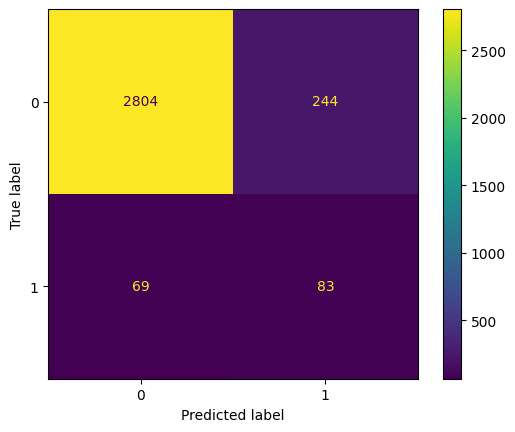

In [27]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_NC, display_labels=nc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4107188807741831


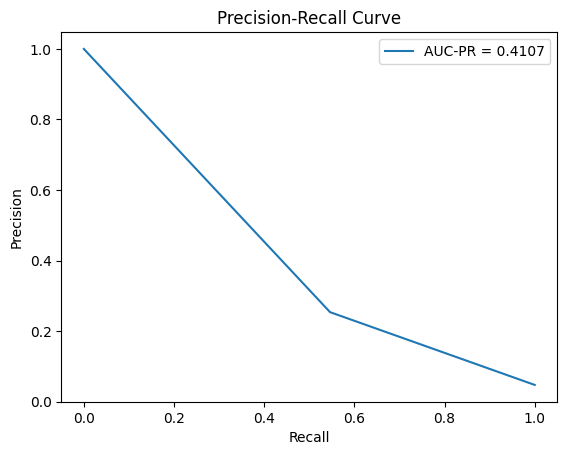

In [28]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_NC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 2. Decision Tree Classifier

In [29]:
# Initialize and train Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_rfe, y_train_rfe)

DecisionTreeClassifier(random_state=42)

In [30]:
# Make predictions
y_pred_DT = dt.predict(X_test_rfe)

In [31]:
# Evaluating the model
accuracy_DT = accuracy_score(y_test_rfe, y_pred_DT)
conf_matrix_DT = confusion_matrix(y_test_rfe, y_pred_DT)
class_report_DT = classification_report(y_test_rfe, y_pred_DT)

TP = conf_matrix_DT[1, 1]
FN = conf_matrix_DT[1, 0]
FP = conf_matrix_DT[0, 1]
TN = conf_matrix_DT[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_DT:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_DT)

Evaluation Metrics:
Accuracy: 0.9359
True Positive Rate (TPR): 0.4474
False Positive Rate (FPR): 0.0397
Balanced Accuracy: 0.7038

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3048
           1       0.36      0.45      0.40       152

    accuracy                           0.94      3200
   macro avg       0.67      0.70      0.68      3200
weighted avg       0.94      0.94      0.94      3200



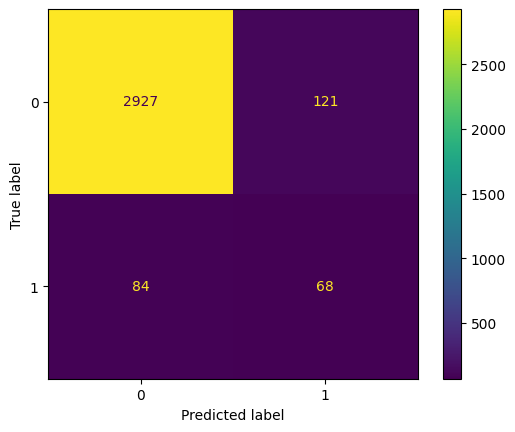

In [32]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_DT, display_labels=dt.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4167033904204957


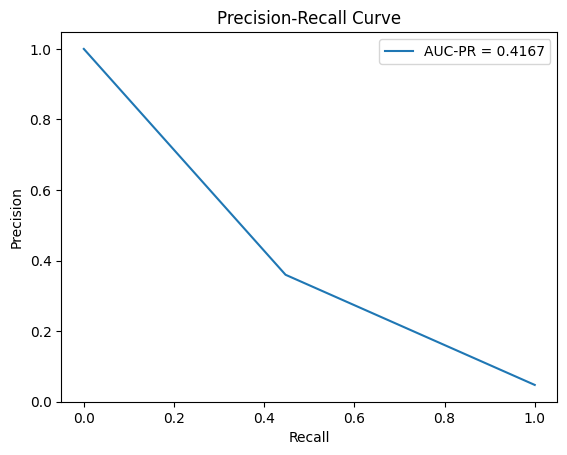

In [33]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_DT)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 3. Linear Discriminant Analysis

In [34]:
# Initialize and train Model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_rfe, y_train_rfe)

LinearDiscriminantAnalysis()

In [35]:
# Make predictions
y_pred_LDA = lda.predict(X_test_rfe)

In [36]:
# Evaluating the model
accuracy_LDA = accuracy_score(y_test_rfe, y_pred_LDA)
conf_matrix_LDA = confusion_matrix(y_test_rfe, y_pred_LDA)
class_report_LDA = classification_report(y_test_rfe, y_pred_LDA)

TP = conf_matrix_LDA[1, 1]
FN = conf_matrix_LDA[1, 0]
FP = conf_matrix_LDA[0, 1]
TN = conf_matrix_LDA[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_LDA:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_LDA)

Evaluation Metrics:
Accuracy: 0.9575
True Positive Rate (TPR): 0.4145
False Positive Rate (FPR): 0.0154
Balanced Accuracy: 0.6995

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3048
           1       0.57      0.41      0.48       152

    accuracy                           0.96      3200
   macro avg       0.77      0.70      0.73      3200
weighted avg       0.95      0.96      0.95      3200



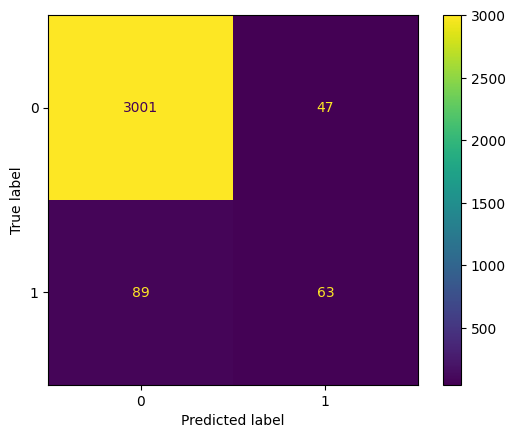

In [37]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LDA, display_labels=lda.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5075067284688995


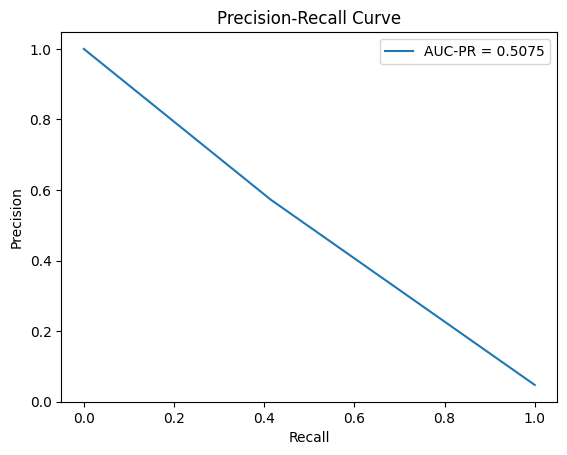

In [38]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_LDA)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 4. Bagging Classifier

In [39]:
# Initialize and train Model
bagging = BaggingClassifier(random_state=42)
bagging.fit(X_train_rfe, y_train_rfe)

BaggingClassifier(random_state=42)

In [40]:
# Make predictions
y_pred_BAG = bagging.predict(X_test_rfe)

In [41]:
# Evaluating the model
accuracy_BAG = accuracy_score(y_test_rfe, y_pred_BAG)
conf_matrix_BAG = confusion_matrix(y_test_rfe, y_pred_BAG)
class_report_BAG = classification_report(y_test_rfe, y_pred_BAG)

TP = conf_matrix_BAG[1, 1]
FN = conf_matrix_BAG[1, 0]
FP = conf_matrix_BAG[0, 1]
TN = conf_matrix_BAG[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_BAG:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_BAG)

Evaluation Metrics:
Accuracy: 0.9628
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0079
Balanced Accuracy: 0.6836

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.70      0.38      0.49       152

    accuracy                           0.96      3200
   macro avg       0.84      0.68      0.73      3200
weighted avg       0.96      0.96      0.96      3200



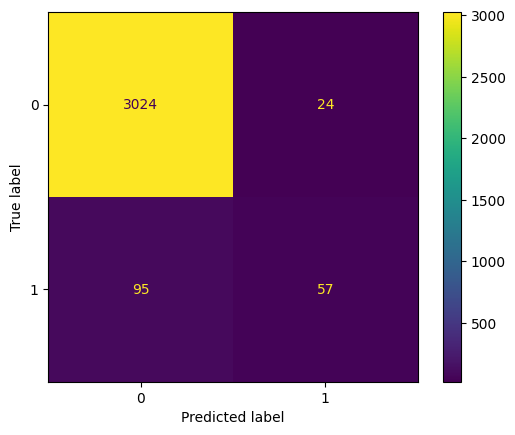

In [42]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BAG, display_labels=bagging.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5541956018518518


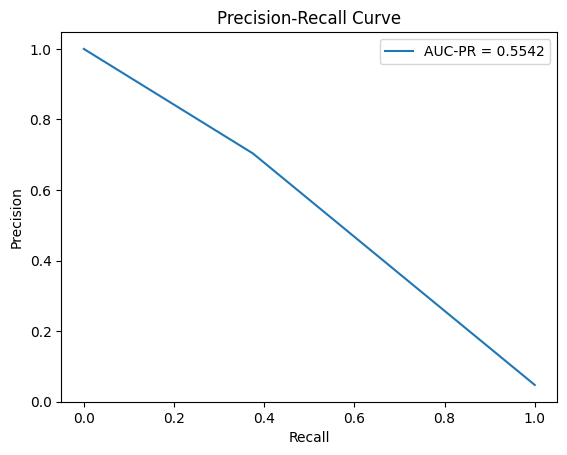

In [43]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_BAG)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 5. Perceptron

In [44]:
# Initialize and train Model
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train_rfe, y_train_rfe)

Perceptron(random_state=42)

In [45]:
# Make predictions
y_pred_PRC = perceptron.predict(X_test_rfe)

In [46]:
# Evaluating the model
accuracy_PRC = accuracy_score(y_test_rfe, y_pred_PRC)
conf_matrix_PRC = confusion_matrix(y_test_rfe, y_pred_PRC)
class_report_PRC = classification_report(y_test_rfe, y_pred_PRC)

TP = conf_matrix_PRC[1, 1]
FN = conf_matrix_PRC[1, 0]
FP = conf_matrix_PRC[0, 1]
TN = conf_matrix_PRC[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_PRC:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_PRC)

Evaluation Metrics:
Accuracy: 0.9384
True Positive Rate (TPR): 0.3487
False Positive Rate (FPR): 0.0322
Balanced Accuracy: 0.6583

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3048
           1       0.35      0.35      0.35       152

    accuracy                           0.94      3200
   macro avg       0.66      0.66      0.66      3200
weighted avg       0.94      0.94      0.94      3200



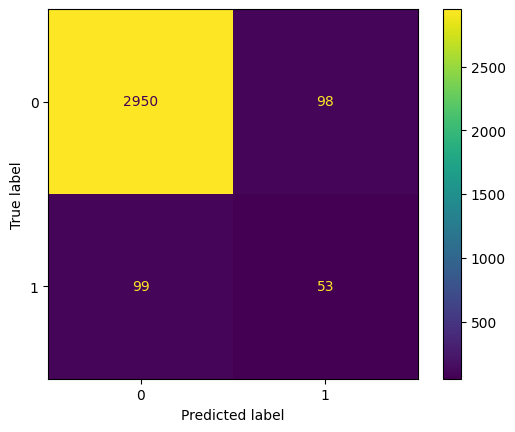

In [47]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_PRC, display_labels=perceptron.classes_)
disp.plot()
plt.show()

AUC-PR: 0.36530754400487975


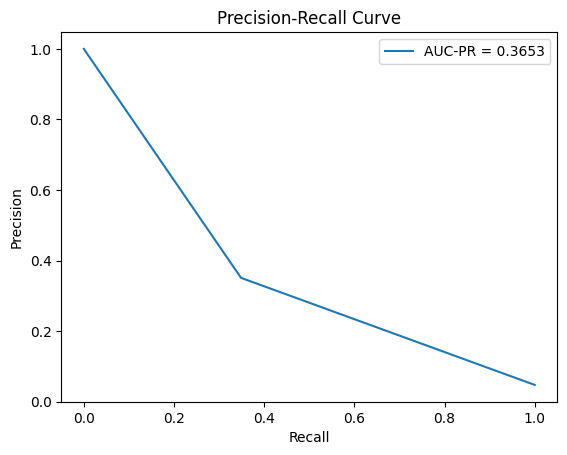

In [48]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_PRC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 6. XGB Classfier

In [49]:
# Initialize and train Model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_rfe, y_train_rfe)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [50]:
# Make predictions
y_pred_XGB = xgb.predict(X_test_rfe)

In [51]:
# Evaluating the model
accuracy_XGB = accuracy_score(y_test_rfe, y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test_rfe, y_pred_XGB)
class_report_XGB = classification_report(y_test_rfe, y_pred_XGB)

TP = conf_matrix_XGB[1, 1]
FN = conf_matrix_XGB[1, 0]
FP = conf_matrix_XGB[0, 1]
TN = conf_matrix_XGB[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_XGB:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_XGB)

Evaluation Metrics:
Accuracy: 0.9659
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0056
Balanced Accuracy: 0.6946

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.78      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.87      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



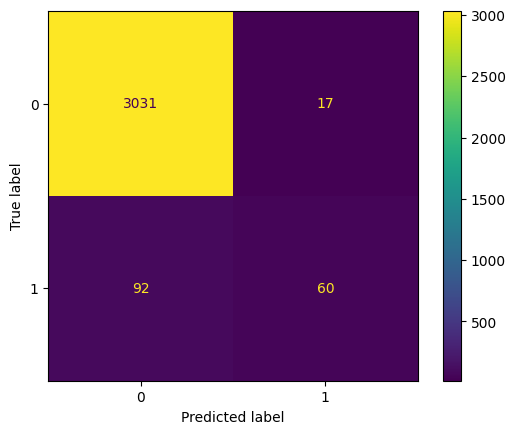

In [52]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_XGB, display_labels=xgb.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6013538106630212


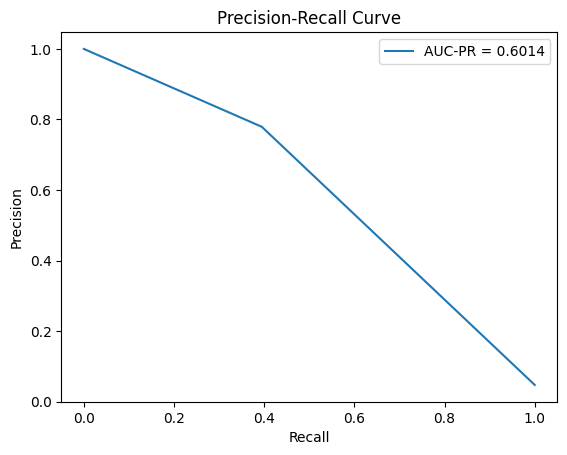

In [53]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_XGB)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 7. LGBM Classifier

In [54]:
# Initialize and train Model
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002405 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


LGBMClassifier(random_state=42)

In [55]:
# Make predictions
y_pred_LGBM = lgbm.predict(X_test_rfe)

In [56]:
# Evaluating the model
accuracy_LGBM = accuracy_score(y_test_rfe, y_pred_LGBM)
conf_matrix_LGBM = confusion_matrix(y_test_rfe, y_pred_LGBM)
class_report_LGBM = classification_report(y_test_rfe, y_pred_LGBM)

TP = conf_matrix_LGBM[1, 1]
FN = conf_matrix_LGBM[1, 0]
FP = conf_matrix_LGBM[0, 1]
TN = conf_matrix_LGBM[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_LGBM:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_LGBM)

Evaluation Metrics:
Accuracy: 0.9628
True Positive Rate (TPR): 0.3618
False Positive Rate (FPR): 0.0072
Balanced Accuracy: 0.6773

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.71      0.36      0.48       152

    accuracy                           0.96      3200
   macro avg       0.84      0.68      0.73      3200
weighted avg       0.96      0.96      0.96      3200



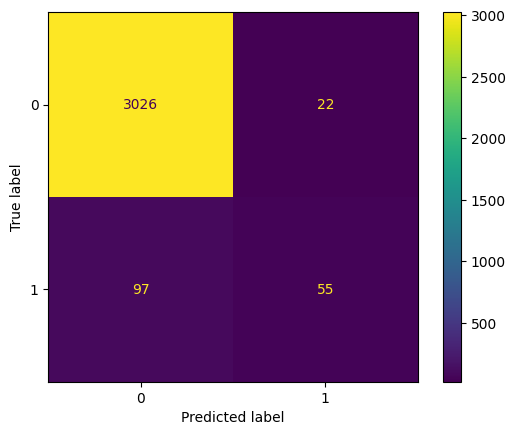

In [57]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LGBM, display_labels=lgbm.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5517936872033521


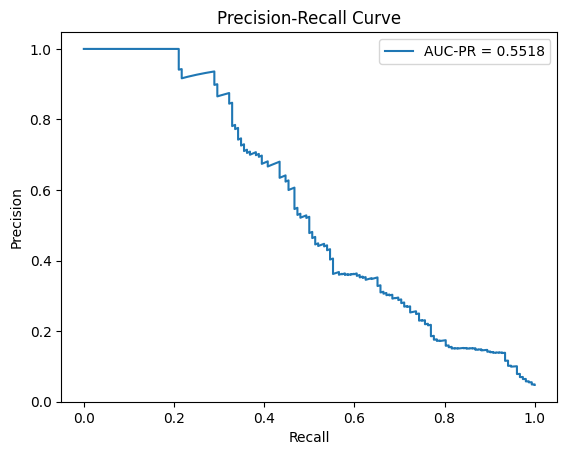

In [58]:
# AUC-PR (uses predicted probabilities)
y_scores_LGBM = lgbm.predict_proba(X_test_rfe)[:, 1]
precision, recall, _ = precision_recall_curve(y_test_rfe, y_scores_LGBM)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 8. BernoulliNB Classifier

In [59]:
# Initialize and train Model
bnb = BernoulliNB()
bnb.fit(X_train_rfe, y_train_rfe)

BernoulliNB()

In [60]:
# Make predictions
y_pred_BNB = bnb.predict(X_test_rfe)

In [61]:
# Evaluating the model
accuracy_BNB = accuracy_score(y_test_rfe, y_pred_BNB)
conf_matrix_BNB = confusion_matrix(y_test_rfe, y_pred_BNB)
class_report_BNB = classification_report(y_test_rfe, y_pred_BNB)

TP = conf_matrix_BNB[1, 1]
FN = conf_matrix_BNB[1, 0]
FP = conf_matrix_BNB[0, 1]
TN = conf_matrix_BNB[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_BNB:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_BNB)

Evaluation Metrics:
Accuracy: 0.9038
True Positive Rate (TPR): 0.5000
False Positive Rate (FPR): 0.0761
Balanced Accuracy: 0.7119

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      3048
           1       0.25      0.50      0.33       152

    accuracy                           0.90      3200
   macro avg       0.61      0.71      0.64      3200
weighted avg       0.94      0.90      0.92      3200



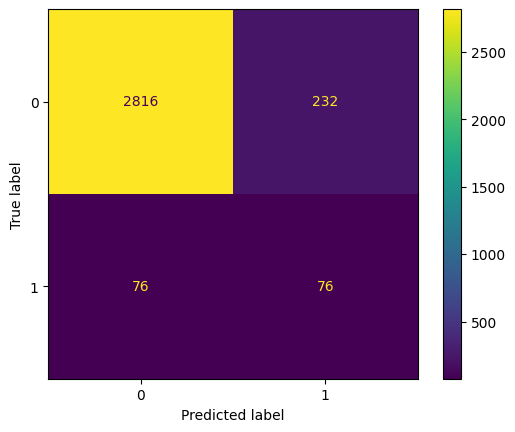

In [62]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_BNB, display_labels=bnb.classes_)
disp.plot()
plt.show()

AUC-PR: 0.34370323899168653


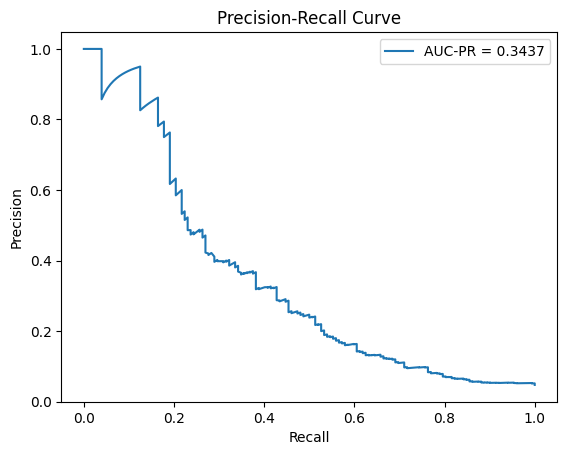

In [63]:
# AUC-PR (uses predicted probabilities)
y_scores_BNB = bnb.predict_proba(X_test_rfe)[:, 1]
precision, recall, _ = precision_recall_curve(y_test_rfe, y_scores_BNB)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 9. Random Forest Classifier

In [64]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_rfe, y_train_rfe)

RandomForestClassifier(random_state=42)

In [65]:
# Make predictions
y_pred_RF = rf.predict(X_test_rfe)

In [66]:
# Evaluating the model
accuracy_RF = accuracy_score(y_test_rfe, y_pred_RF)
conf_matrix_RF = confusion_matrix(y_test_rfe, y_pred_RF)
class_report_RF = classification_report(y_test_rfe, y_pred_RF)

TP = conf_matrix_RF[1, 1]
FN = conf_matrix_RF[1, 0]
FP = conf_matrix_RF[0, 1]
TN = conf_matrix_RF[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_RF:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_RF)

Evaluation Metrics:
Accuracy: 0.9656
True Positive Rate (TPR): 0.3487
False Positive Rate (FPR): 0.0036
Balanced Accuracy: 0.6725

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.83      0.35      0.49       152

    accuracy                           0.97      3200
   macro avg       0.90      0.67      0.74      3200
weighted avg       0.96      0.97      0.96      3200



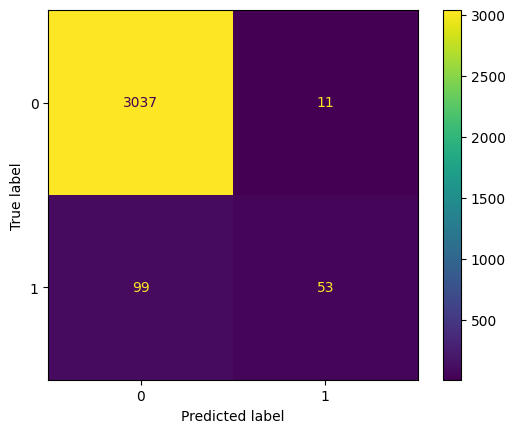

In [67]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_RF, display_labels=rf.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6038733552631579


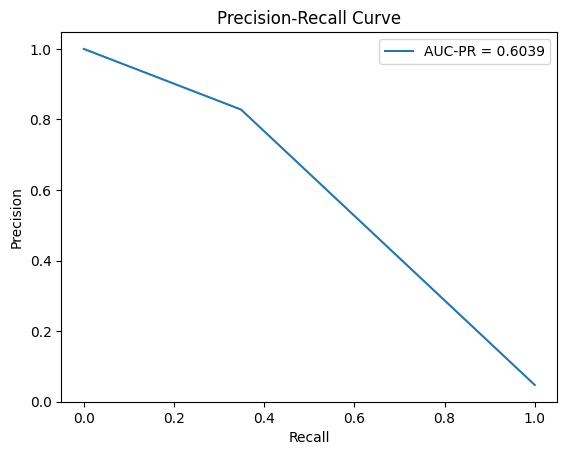

In [68]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_RF)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 10. SGD Classifier

In [69]:
# Initialize and train Model
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train_rfe, y_train_rfe)

SGDClassifier(random_state=42)

In [70]:
# Make predictions
y_pred_SGD = sgd.predict(X_test_rfe)

In [71]:
# Evaluating the model
accuracy_SGD = accuracy_score(y_test_rfe, y_pred_SGD)
conf_matrix_SGD = confusion_matrix(y_test_rfe, y_pred_SGD)
class_report_SGD = classification_report(y_test_rfe, y_pred_SGD)

TP = conf_matrix_SGD[1, 1]
FN = conf_matrix_SGD[1, 0]
FP = conf_matrix_SGD[0, 1]
TN = conf_matrix_SGD[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_SGD:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_SGD)

Evaluation Metrics:
Accuracy: 0.9537
True Positive Rate (TPR): 0.0526
False Positive Rate (FPR): 0.0013
Balanced Accuracy: 0.5257

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3048
           1       0.67      0.05      0.10       152

    accuracy                           0.95      3200
   macro avg       0.81      0.53      0.54      3200
weighted avg       0.94      0.95      0.93      3200



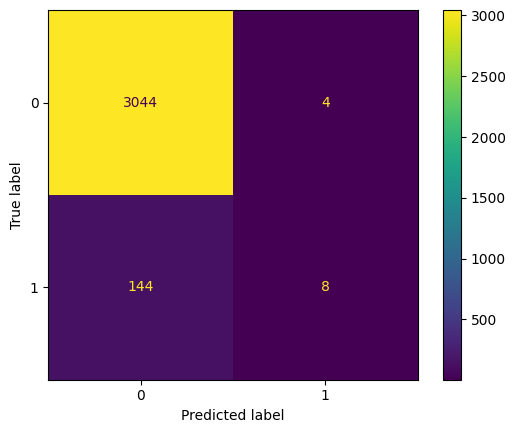

In [72]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SGD, display_labels=sgd.classes_)
disp.plot()
plt.show()

AUC-PR: 0.3821491228070175


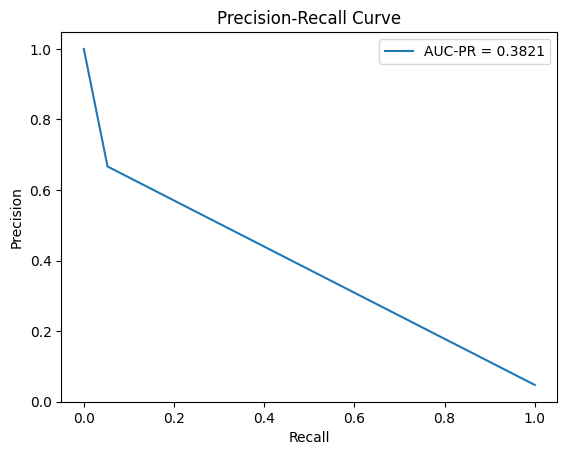

In [73]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_SGD)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 11. Extra Trees Classifier

In [74]:
# Initialize and train Model
et = ExtraTreesClassifier(random_state=42)
et.fit(X_train_rfe, y_train_rfe)

ExtraTreesClassifier(random_state=42)

In [75]:
# Make predictions
y_pred_ET = et.predict(X_test_rfe)

In [76]:
# Evaluating the model
accuracy_ET = accuracy_score(y_test_rfe, y_pred_ET)
conf_matrix_ET = confusion_matrix(y_test_rfe, y_pred_ET)
class_report_ET = classification_report(y_test_rfe, y_pred_ET)

TP = conf_matrix_ET[1, 1]
FN = conf_matrix_ET[1, 0]
FP = conf_matrix_ET[0, 1]
TN = conf_matrix_ET[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_ET:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_ET)

Evaluation Metrics:
Accuracy: 0.9663
True Positive Rate (TPR): 0.3421
False Positive Rate (FPR): 0.0026
Balanced Accuracy: 0.6697

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.87      0.34      0.49       152

    accuracy                           0.97      3200
   macro avg       0.92      0.67      0.74      3200
weighted avg       0.96      0.97      0.96      3200



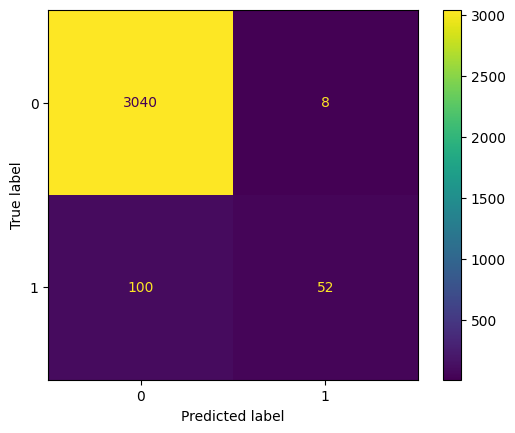

In [77]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ET, display_labels=et.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6200109649122807


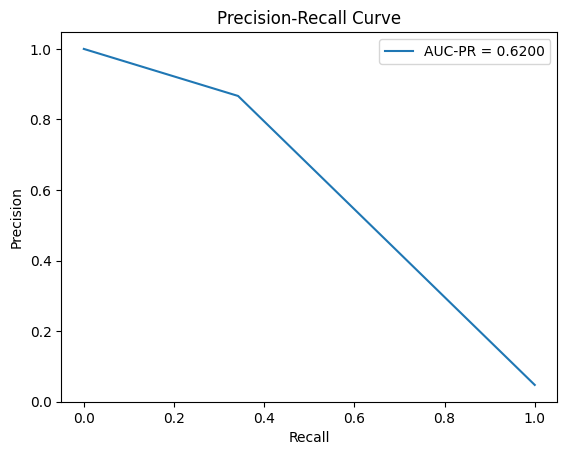

In [78]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_ET)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Stacking Ensemble Model

In [79]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [80]:
# Base models
base_models = [
    ('nc', NearestCentroid()),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('lda', LinearDiscriminantAnalysis()),
    ('bagging', BaggingClassifier(random_state=42)),
    ('perceptron', Perceptron(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('bnb', BernoulliNB()),
    ('rf', RandomForestClassifier(random_state=42)),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreesClassifier(random_state=42))
]

In [81]:
# Meta-learner
meta_learner = LogisticRegression()

In [82]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

In [83]:
# Train model
stacking_model.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004496 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002948 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('nc', NearestCentroid()),
                               ('dt', DecisionTreeClassifier(random_state=42)),
                               ('lda', LinearDiscriminantAnalysis()),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('perceptron', Perceptron(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsa...
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('bnb', BernoulliNB()),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreesClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [84]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test_rfe)

In [85]:
# Evaluating the model
accuracy_stack = accuracy_score(y_test_rfe, y_pred_stack)
conf_matrix_stack = confusion_matrix(y_test_rfe, y_pred_stack)
class_report_stack = classification_report(y_test_rfe, y_pred_stack)

TP = conf_matrix_stack[1, 1]
FN = conf_matrix_stack[1, 0]
FP = conf_matrix_stack[0, 1]
TN = conf_matrix_stack[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics:")
print(f'Accuracy: {accuracy_stack:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack)

Evaluation Metrics:
Accuracy: 0.9672
True Positive Rate (TPR): 0.4079
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.7015

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.41      0.54       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



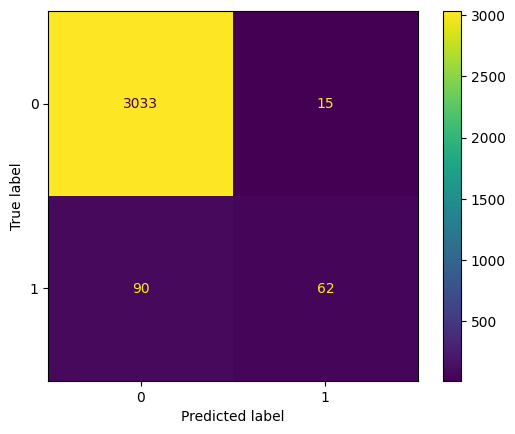

In [86]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack, display_labels=stacking_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.6206


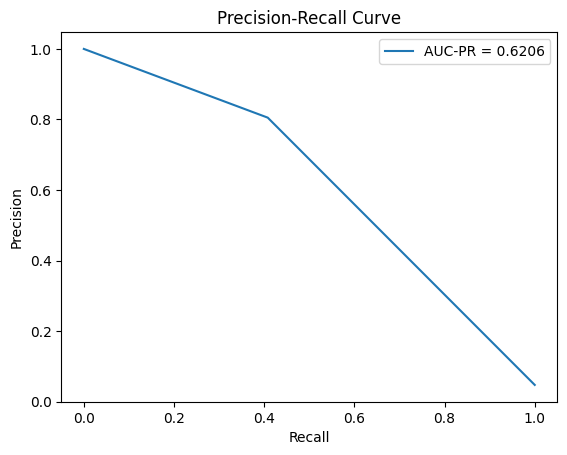

In [87]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_stack)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# SHAP - Stacking Ensemble

In [88]:
import shap

In [89]:
# Meta-learner
meta_learner = stacking_model.final_estimator_

In [90]:
# Transformed features
X_test_meta = stacking_model.transform(X_test_rfe)

In [91]:
# Feature Names
base_model_names = [name for name, _ in base_models]
feature_names = []

for model_name in base_model_names:
    feature_names.append(f"{model_name}_prediction")

In [92]:
# DataFrame
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

In [93]:
# SHAP explainer
explainer = shap.Explainer(meta_learner, X_test_meta_df)
shap_values = explainer(X_test_meta_df)

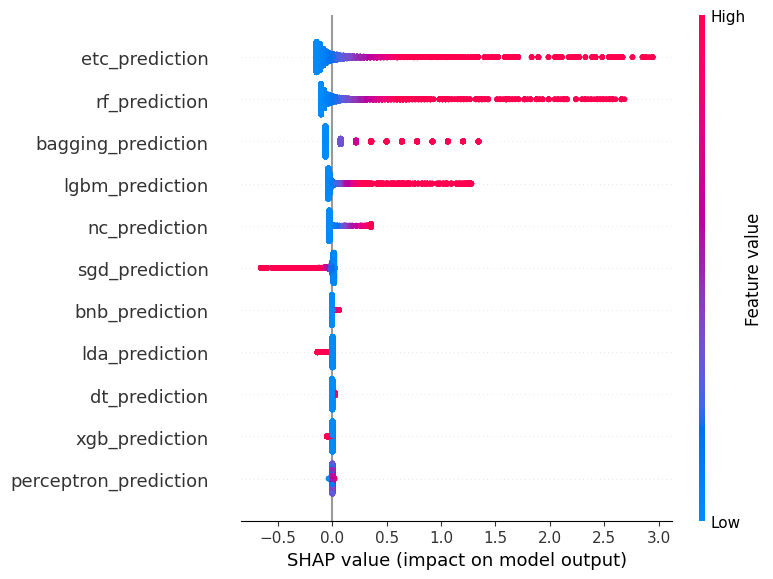

In [94]:
# Subsample
sample_indices = np.random.choice(len(X_test_meta_df), size=16000, replace=True)
shap_values_sampled = shap_values[sample_indices]
X_test_meta_sampled = X_test_meta_df.iloc[sample_indices]

shap.summary_plot(shap_values_sampled, X_test_meta_sampled)

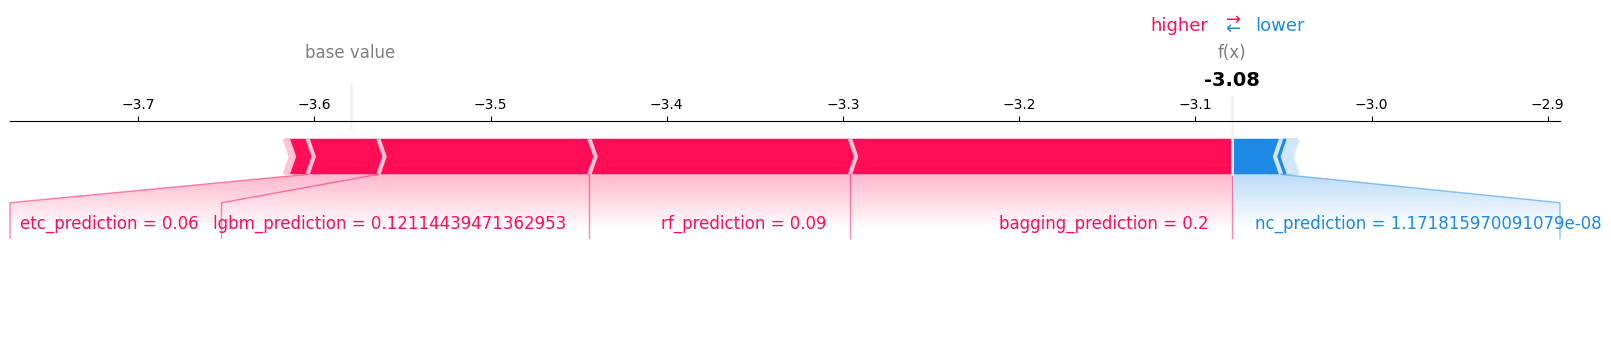

In [95]:
# Force Plot
idx = np.random.randint(len(X_test_meta_sampled))
shap.force_plot(explainer.expected_value, shap_values_sampled[idx].values, X_test_meta_sampled.iloc[idx], matplotlib=True)

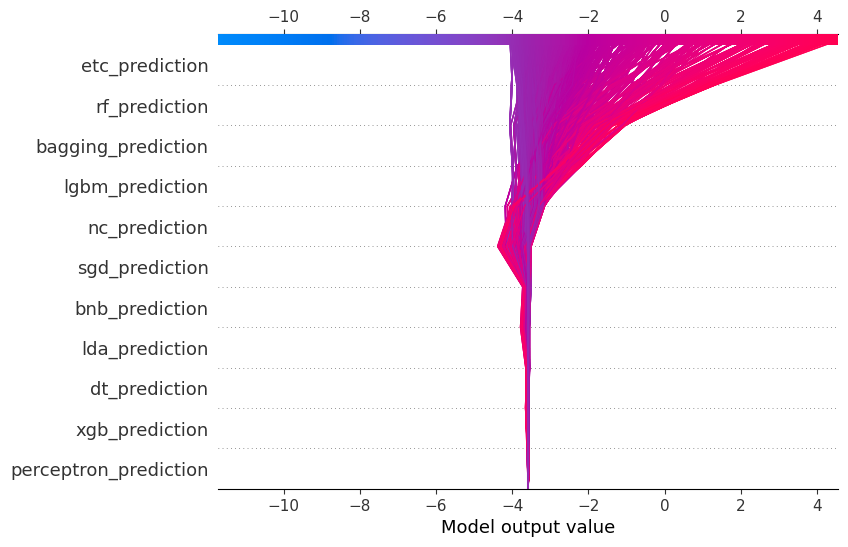

In [96]:
# Decision Plot
shap.decision_plot(explainer.expected_value, shap_values_sampled.values, X_test_meta_sampled, ignore_warnings=True)
plt.show()

## The Best performing Models in the Stack:
1. **Extra Trees Classifier (ETC)**
2. **Random Forest Classifier**
3. **Bagging Classifier**
4. **Light Gradient Boosting Machine Classifier (LGBM)**
5. **Nearest Centroid**

# Reduced Stacking Ensembles

In this section, we're calculating the number of unique combinations possible when selecting a subset of models from a pool of 5 top-performing models. This is to understand the various configurations we could use for a refined stacking ensemble, where at least two models are chosen for a combination.

The formula for combinations, $C(n, k)$, is used for this purpose:

$C(n,k) = \frac{n!}{k! \cdot (n-k)!}$

Where:
* $n$ = total number of models (5)
* $k$ = number of models chosen for a combination

Let's calculate the combinations for different sizes of subsets:

* **Choosing 5 models:** $C(5,5) = \frac{5!}{5! \cdot 0!} = 1$ (Remember $0! = 1$)
* **Choosing 4 models:** $C(5,4) = \frac{5!}{4! \cdot 1!} = 5$
* **Choosing 3 models:** $C(5,3) = \frac{5!}{3! \cdot 2!} = \frac{(5 \cdot 4)}{(2 \cdot 1)} = 10$
* **Choosing 2 models:** $C(5,2) = \frac{5!}{2! \cdot 3!} = \frac{(5 \cdot 4)}{(2 \cdot 1)} = 10$

**Total combinations = 10 + 10 + 5 + 1 = 26**

# Combinations of 5 Models:

## 1. Reduced-1 - ETC, RF, Bagging, LGBM, NC

In [97]:
# Base models (Updated Reduced1)
reduced1_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [98]:
# Meta-learner
meta_learner_reduced1 = LogisticRegression()

In [99]:
# Stacking Classifier
stacking_model_reduced1 = StackingClassifier(
    estimators=reduced1_models,
    final_estimator=meta_learner_reduced1,
    cv=5
)

In [100]:
# Train model
stacking_model_reduced1.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005094 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [101]:
# Predict
y_pred_stack_reduced1 = stacking_model_reduced1.predict(X_test_rfe)

In [102]:
# Evaluating the model
accuracy_stack_reduced1 = accuracy_score(y_test_rfe, y_pred_stack_reduced1)
conf_matrix_stack_reduced1 = confusion_matrix(y_test_rfe, y_pred_stack_reduced1)
class_report_stack_reduced1 = classification_report(y_test_rfe, y_pred_stack_reduced1)

TP = conf_matrix_stack_reduced1[1, 1]
FN = conf_matrix_stack_reduced1[1, 0]
FP = conf_matrix_stack_reduced1[0, 1]
TN = conf_matrix_stack_reduced1[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced1):")
print(f'Accuracy: {accuracy_stack_reduced1:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced1)

Evaluation Metrics (Reduced1):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.6947

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.79      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



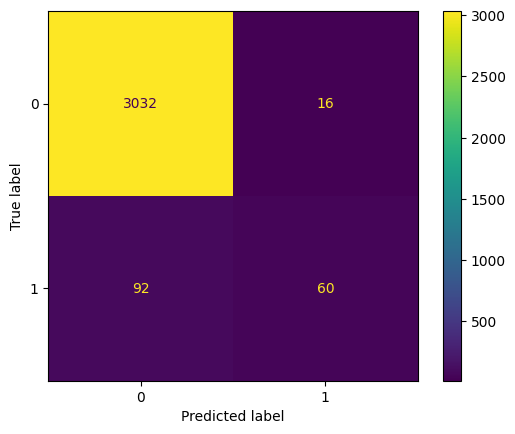

In [103]:
# Confusion matrix
conf_matrix_stack_reduced1 = confusion_matrix(y_test_rfe, y_pred_stack_reduced1)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced1, display_labels=stacking_model_reduced1.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced1): 0.6065


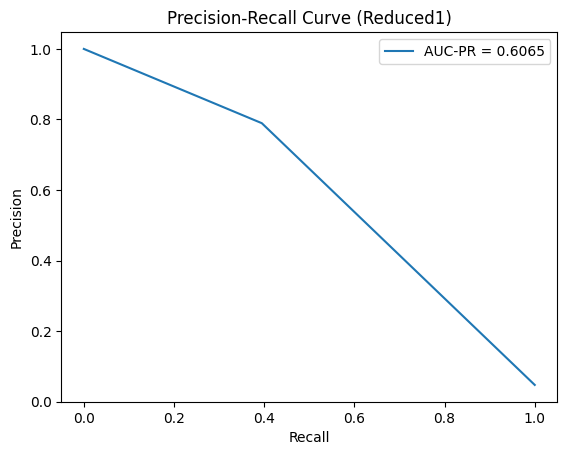

In [104]:
# AUC-PR
precision_reduced1, recall_reduced1, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced1)
auc_pr_reduced1 = auc(recall_reduced1, precision_reduced1)
print(f"AUC-PR (Reduced1): {auc_pr_reduced1:.4f}")

plt.plot(recall_reduced1, precision_reduced1, label=f'AUC-PR = {auc_pr_reduced1:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced1)')
plt.legend()
plt.show()

# Combinations of 4 Models:

## 2. Reduced-2 - ETC, RF, Bagging, LGBM

In [105]:
# Base models (Reduced2)
reduced2_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [106]:
# Meta-learner
meta_learner_reduced2 = LogisticRegression()

In [107]:
# Stacking Classifier
stacking_model_reduced2 = StackingClassifier(
    estimators=reduced2_models,
    final_estimator=meta_learner_reduced2,
    cv=5
)

In [108]:
# Train model
stacking_model_reduced2.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002548 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [109]:
# Predict
y_pred_stack_reduced2 = stacking_model_reduced2.predict(X_test_rfe)

In [110]:
# Evaluating the model
accuracy_stack_reduced2 = accuracy_score(y_test_rfe, y_pred_stack_reduced2)
conf_matrix_stack_reduced2 = confusion_matrix(y_test_rfe, y_pred_stack_reduced2)
class_report_stack_reduced2 = classification_report(y_test_rfe, y_pred_stack_reduced2)

TP = conf_matrix_stack_reduced2[1, 1]
FN = conf_matrix_stack_reduced2[1, 0]
FP = conf_matrix_stack_reduced2[0, 1]
TN = conf_matrix_stack_reduced2[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced2):")
print(f'Accuracy: {accuracy_stack_reduced2:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced2)

Evaluation Metrics (Reduced2):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6916

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



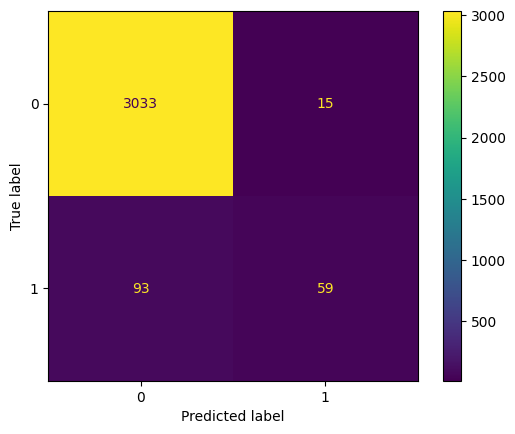

In [111]:
# Confusion matrix
conf_matrix_stack_reduced2 = confusion_matrix(y_test_rfe, y_pred_stack_reduced2)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced2, display_labels=stacking_model_reduced2.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced2): 0.6073


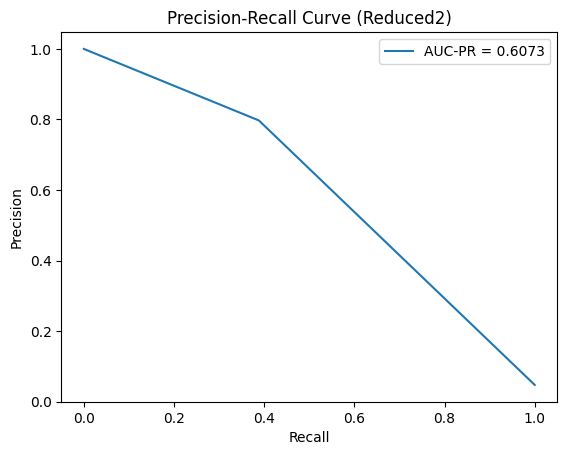

In [112]:
# AUC-PR
precision_reduced2, recall_reduced2, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced2)
auc_pr_reduced2 = auc(recall_reduced2, precision_reduced2)
print(f"AUC-PR (Reduced2): {auc_pr_reduced2:.4f}")

plt.plot(recall_reduced2, precision_reduced2, label=f'AUC-PR = {auc_pr_reduced2:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced2)')
plt.legend()
plt.show()

## 3. Reduced-3 - ETC, RF, Bagging, NC

In [113]:
# Base models (Reduced3)
reduced3_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [114]:
# Meta-learner
meta_learner_reduced3 = LogisticRegression()

In [115]:
# Stacking Classifier
stacking_model_reduced3 = StackingClassifier(
    estimators=reduced3_models,
    final_estimator=meta_learner_reduced3,
    cv=5
)

In [116]:
# Train model
stacking_model_reduced3.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [117]:
# Predict
y_pred_stack_reduced3 = stacking_model_reduced3.predict(X_test_rfe)

In [118]:
# Evaluating the model
accuracy_stack_reduced3 = accuracy_score(y_test_rfe, y_pred_stack_reduced3)
conf_matrix_stack_reduced3 = confusion_matrix(y_test_rfe, y_pred_stack_reduced3)
class_report_stack_reduced3 = classification_report(y_test_rfe, y_pred_stack_reduced3)

TP = conf_matrix_stack_reduced3[1, 1]
FN = conf_matrix_stack_reduced3[1, 0]
FP = conf_matrix_stack_reduced3[0, 1]
TN = conf_matrix_stack_reduced3[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced3):")
print(f'Accuracy: {accuracy_stack_reduced3:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced3)

Evaluation Metrics (Reduced3):
Accuracy: 0.9659
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.6915

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.79      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



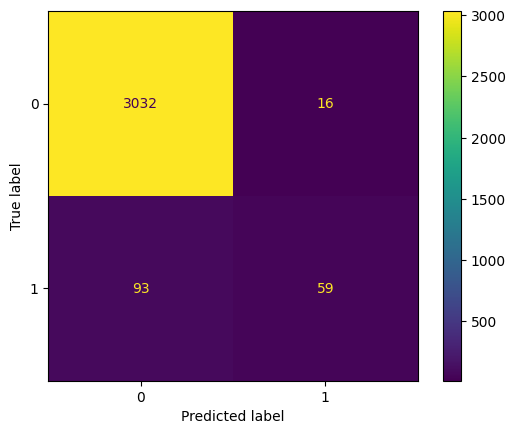

In [119]:
# Confusion matrix
conf_matrix_stack_reduced3 = confusion_matrix(y_test_rfe, y_pred_stack_reduced3)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced3, display_labels=stacking_model_reduced3.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced3): 0.6019


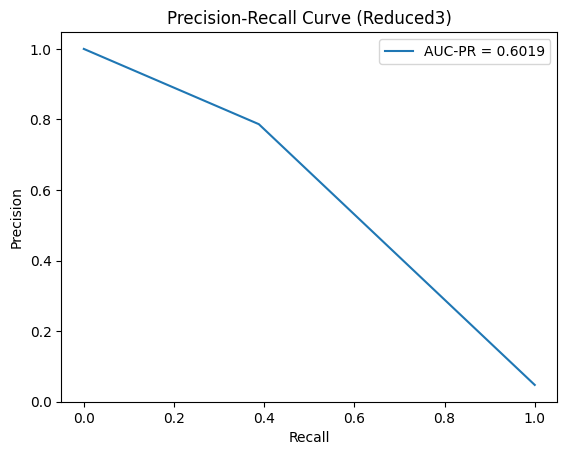

In [120]:
# AUC-PR
precision_reduced3, recall_reduced3, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced3)
auc_pr_reduced3 = auc(recall_reduced3, precision_reduced3)
print(f"AUC-PR (Reduced3): {auc_pr_reduced3:.4f}")

plt.plot(recall_reduced3, precision_reduced3, label=f'AUC-PR = {auc_pr_reduced3:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced3)')
plt.legend()
plt.show()

## 4. Reduced-4 - ETC, RF, LGBM, NC

In [121]:
# Base models (Reduced4)
reduced4_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [122]:
# Meta-learner
meta_learner_reduced4 = LogisticRegression()

In [123]:
# Stacking Classifier
stacking_model_reduced4 = StackingClassifier(
    estimators=reduced4_models,
    final_estimator=meta_learner_reduced4,
    cv=5
)

In [124]:
# Train model
stacking_model_reduced4.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001707 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [125]:
# Predict
y_pred_stack_reduced4 = stacking_model_reduced4.predict(X_test_rfe)

In [126]:
# Evaluating the model
accuracy_stack_reduced4 = accuracy_score(y_test_rfe, y_pred_stack_reduced4)
conf_matrix_stack_reduced4 = confusion_matrix(y_test_rfe, y_pred_stack_reduced4)
class_report_stack_reduced4 = classification_report(y_test_rfe, y_pred_stack_reduced4)

TP = conf_matrix_stack_reduced4[1, 1]
FN = conf_matrix_stack_reduced4[1, 0]
FP = conf_matrix_stack_reduced4[0, 1]
TN = conf_matrix_stack_reduced4[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced4):")
print(f'Accuracy: {accuracy_stack_reduced4:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced4)

Evaluation Metrics (Reduced4):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3816
False Positive Rate (FPR): 0.0046
Balanced Accuracy: 0.6885

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.38      0.52       152

    accuracy                           0.97      3200
   macro avg       0.89      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



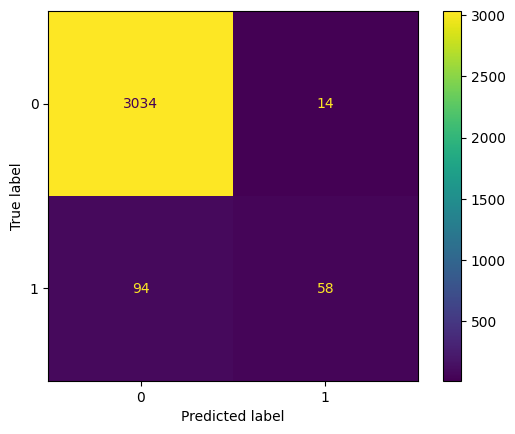

In [127]:
# Confusion matrix
conf_matrix_stack_reduced4 = confusion_matrix(y_test_rfe, y_pred_stack_reduced4)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced4, display_labels=stacking_model_reduced4.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced4): 0.6083


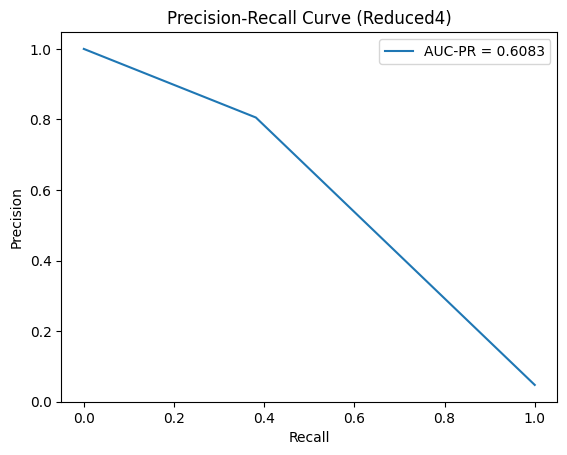

In [128]:
# AUC-PR
precision_reduced4, recall_reduced4, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced4)
auc_pr_reduced4 = auc(recall_reduced4, precision_reduced4)
print(f"AUC-PR (Reduced4): {auc_pr_reduced4:.4f}")

plt.plot(recall_reduced4, precision_reduced4, label=f'AUC-PR = {auc_pr_reduced4:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced4)')
plt.legend()
plt.show()

## 5. Reduced-5 - ETC, Bagging, LGBM, NC

In [129]:
# Base models (Reduced5)
reduced5_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [130]:
# Meta-learner
meta_learner_reduced5 = LogisticRegression()

In [131]:
# Stacking Classifier
stacking_model_reduced5 = StackingClassifier(
    estimators=reduced5_models,
    final_estimator=meta_learner_reduced5,
    cv=5
)

In [132]:
# Train model
stacking_model_reduced5.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001960 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001757 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [133]:
# Predict
y_pred_stack_reduced5 = stacking_model_reduced5.predict(X_test_rfe)

In [134]:
# Evaluating the model
accuracy_stack_reduced5 = accuracy_score(y_test_rfe, y_pred_stack_reduced5)
conf_matrix_stack_reduced5 = confusion_matrix(y_test_rfe, y_pred_stack_reduced5)
class_report_stack_reduced5 = classification_report(y_test_rfe, y_pred_stack_reduced5)

TP = conf_matrix_stack_reduced5[1, 1]
FN = conf_matrix_stack_reduced5[1, 0]
FP = conf_matrix_stack_reduced5[0, 1]
TN = conf_matrix_stack_reduced5[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced5):")
print(f'Accuracy: {accuracy_stack_reduced5:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced5)

Evaluation Metrics (Reduced5):
Accuracy: 0.9669
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0046
Balanced Accuracy: 0.6951

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



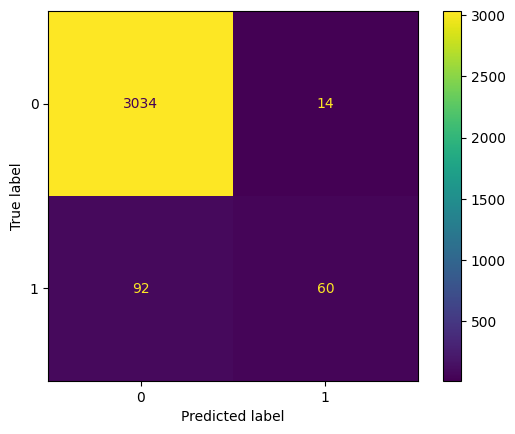

In [135]:
# Confusion matrix
conf_matrix_stack_reduced5 = confusion_matrix(y_test_rfe, y_pred_stack_reduced5)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced5, display_labels=stacking_model_reduced5.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced5): 0.6171


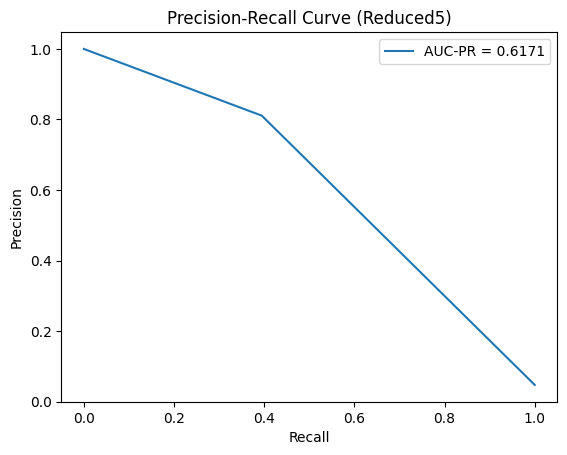

In [136]:
# AUC-PR
precision_reduced5, recall_reduced5, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced5)
auc_pr_reduced5 = auc(recall_reduced5, precision_reduced5)
print(f"AUC-PR (Reduced5): {auc_pr_reduced5:.4f}")

plt.plot(recall_reduced5, precision_reduced5, label=f'AUC-PR = {auc_pr_reduced5:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced5)')
plt.legend()
plt.show()

## 6. Reduced-6 - RF, Bagging, LGBM, NC

In [137]:
# Base models (Reduced6)
reduced6_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [138]:
# Meta-learner
meta_learner_reduced6 = LogisticRegression()

In [139]:
# Stacking Classifier
stacking_model_reduced6 = StackingClassifier(
    estimators=reduced6_models,
    final_estimator=meta_learner_reduced6,
    cv=5
)

In [140]:
# Train model
stacking_model_reduced6.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [141]:
# Predict
y_pred_stack_reduced6 = stacking_model_reduced6.predict(X_test_rfe)

In [142]:
# Evaluating the model
accuracy_stack_reduced6 = accuracy_score(y_test_rfe, y_pred_stack_reduced6)
conf_matrix_stack_reduced6 = confusion_matrix(y_test_rfe, y_pred_stack_reduced6)
class_report_stack_reduced6 = classification_report(y_test_rfe, y_pred_stack_reduced6)

TP = conf_matrix_stack_reduced6[1, 1]
FN = conf_matrix_stack_reduced6[1, 0]
FP = conf_matrix_stack_reduced6[0, 1]
TN = conf_matrix_stack_reduced6[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced6):")
print(f'Accuracy: {accuracy_stack_reduced6:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced6)

Evaluation Metrics (Reduced6):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6916

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



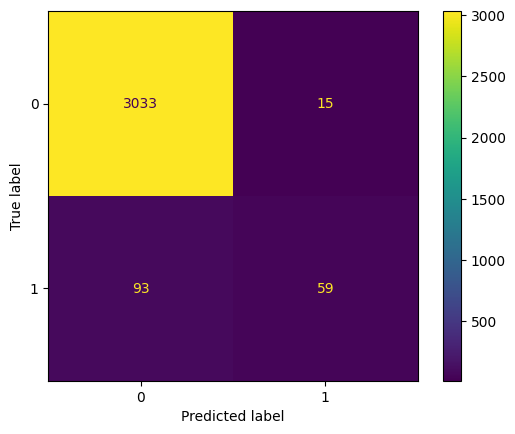

In [143]:
# Confusion matrix
conf_matrix_stack_reduced6 = confusion_matrix(y_test_rfe, y_pred_stack_reduced6)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced6, display_labels=stacking_model_reduced6.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced6): 0.6073


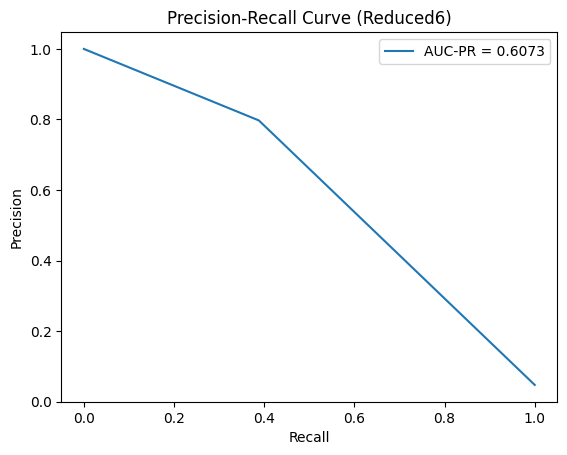

In [144]:
# AUC-PR
precision_reduced6, recall_reduced6, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced6)
auc_pr_reduced6 = auc(recall_reduced6, precision_reduced6)
print(f"AUC-PR (Reduced6): {auc_pr_reduced6:.4f}")

plt.plot(recall_reduced6, precision_reduced6, label=f'AUC-PR = {auc_pr_reduced6:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced6)')
plt.legend()
plt.show()

# Combinations of 3 Models:

## 7. Reduced-7 - ETC, RF, Bagging

In [145]:
# Base models (Reduced7)
reduced7_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42))
]

In [146]:
# Meta-learner
meta_learner_reduced7 = LogisticRegression()

In [147]:
# Stacking Classifier
stacking_model_reduced7 = StackingClassifier(
    estimators=reduced7_models,
    final_estimator=meta_learner_reduced7,
    cv=5
)

In [148]:
# Train model
stacking_model_reduced7.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [149]:
# Predict
y_pred_stack_reduced7 = stacking_model_reduced7.predict(X_test_rfe)

In [150]:
# Evaluating the model
accuracy_stack_reduced7 = accuracy_score(y_test_rfe, y_pred_stack_reduced7)
conf_matrix_stack_reduced7 = confusion_matrix(y_test_rfe, y_pred_stack_reduced7)
class_report_stack_reduced7 = classification_report(y_test_rfe, y_pred_stack_reduced7)

TP = conf_matrix_stack_reduced7[1, 1]
FN = conf_matrix_stack_reduced7[1, 0]
FP = conf_matrix_stack_reduced7[0, 1]
TN = conf_matrix_stack_reduced7[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced7):")
print(f'Accuracy: {accuracy_stack_reduced7:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced7)

Evaluation Metrics (Reduced7):
Accuracy: 0.9666
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0046
Balanced Accuracy: 0.6918

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.89      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



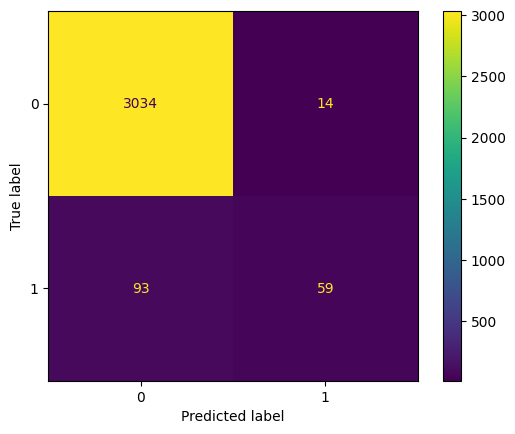

In [151]:
# Confusion matrix
conf_matrix_stack_reduced7 = confusion_matrix(y_test_rfe, y_pred_stack_reduced7)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced7, display_labels=stacking_model_reduced7.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced7): 0.6127


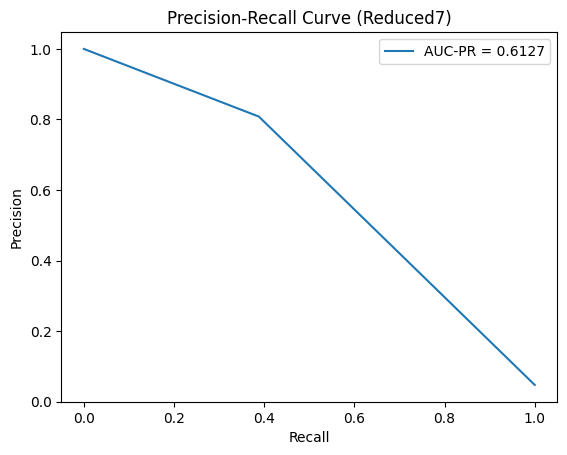

In [152]:
# AUC-PR
precision_reduced7, recall_reduced7, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced7)
auc_pr_reduced7 = auc(recall_reduced7, precision_reduced7)
print(f"AUC-PR (Reduced7): {auc_pr_reduced7:.4f}")

plt.plot(recall_reduced7, precision_reduced7, label=f'AUC-PR = {auc_pr_reduced7:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced7)')
plt.legend()
plt.show()

## 8. Reduced-8 - ETC, RF, LGBM

In [153]:
# Base models (Reduced8)
reduced8_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [154]:
# Meta-learner
meta_learner_reduced8 = LogisticRegression()

In [155]:
# Stacking Classifier
stacking_model_reduced8 = StackingClassifier(
    estimators=reduced8_models,
    final_estimator=meta_learner_reduced8,
    cv=5
)

In [156]:
# Train model
stacking_model_reduced8.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [157]:
# Predict
y_pred_stack_reduced8 = stacking_model_reduced8.predict(X_test_rfe)

In [158]:
# Evaluating the model
accuracy_stack_reduced8 = accuracy_score(y_test_rfe, y_pred_stack_reduced8)
conf_matrix_stack_reduced8 = confusion_matrix(y_test_rfe, y_pred_stack_reduced8)
class_report_stack_reduced8 = classification_report(y_test_rfe, y_pred_stack_reduced8)

TP = conf_matrix_stack_reduced8[1, 1]
FN = conf_matrix_stack_reduced8[1, 0]
FP = conf_matrix_stack_reduced8[0, 1]
TN = conf_matrix_stack_reduced8[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced8):")
print(f'Accuracy: {accuracy_stack_reduced8:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced8)

Evaluation Metrics (Reduced8):
Accuracy: 0.9672
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0039
Balanced Accuracy: 0.6921

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.83      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.90      0.69      0.76      3200
weighted avg       0.96      0.97      0.96      3200



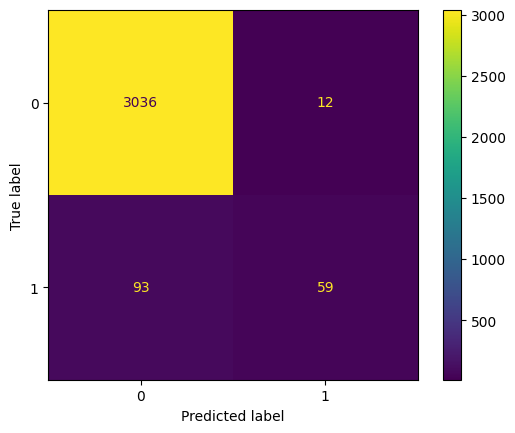

In [159]:
# Confusion matrix
conf_matrix_stack_reduced8 = confusion_matrix(y_test_rfe, y_pred_stack_reduced8)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced8, display_labels=stacking_model_reduced8.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced8): 0.6241


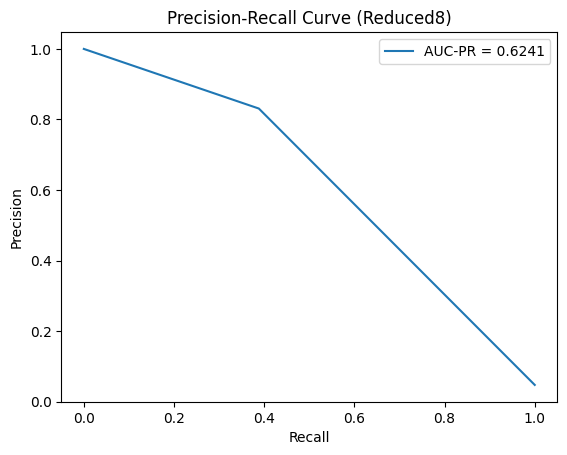

In [160]:
# AUC-PR
precision_reduced8, recall_reduced8, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced8)
auc_pr_reduced8 = auc(recall_reduced8, precision_reduced8)
print(f"AUC-PR (Reduced8): {auc_pr_reduced8:.4f}")

plt.plot(recall_reduced8, precision_reduced8, label=f'AUC-PR = {auc_pr_reduced8:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced8)')
plt.legend()
plt.show()

## 9. Reduced-9 - ETC, RF, NC

In [161]:
# Base models (Reduced9)
reduced9_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('nc', NearestCentroid())
]

In [162]:
# Meta-learner
meta_learner_reduced9 = LogisticRegression()

In [163]:
# Stacking Classifier
stacking_model_reduced9 = StackingClassifier(
    estimators=reduced9_models,
    final_estimator=meta_learner_reduced9,
    cv=5
)

In [164]:
# Train model
stacking_model_reduced9.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [165]:
# Predict
y_pred_stack_reduced9 = stacking_model_reduced9.predict(X_test_rfe)

In [166]:
# Evaluating the model
accuracy_stack_reduced9 = accuracy_score(y_test_rfe, y_pred_stack_reduced9)
conf_matrix_stack_reduced9 = confusion_matrix(y_test_rfe, y_pred_stack_reduced9)
class_report_stack_reduced9 = classification_report(y_test_rfe, y_pred_stack_reduced9)

TP = conf_matrix_stack_reduced9[1, 1]
FN = conf_matrix_stack_reduced9[1, 0]
FP = conf_matrix_stack_reduced9[0, 1]
TN = conf_matrix_stack_reduced9[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced9):")
print(f'Accuracy: {accuracy_stack_reduced9:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced9)

Evaluation Metrics (Reduced9):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6916

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



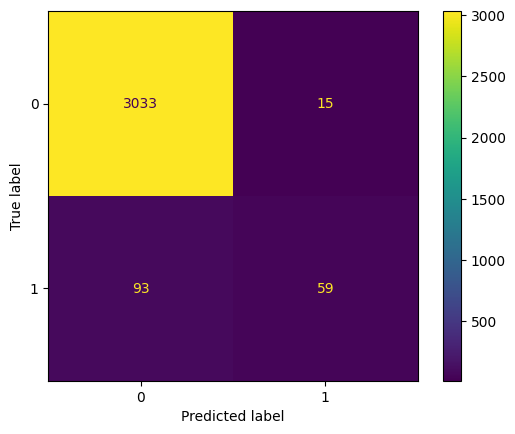

In [167]:
# Confusion matrix
conf_matrix_stack_reduced9 = confusion_matrix(y_test_rfe, y_pred_stack_reduced9)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced9, display_labels=stacking_model_reduced9.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced9): 0.6073


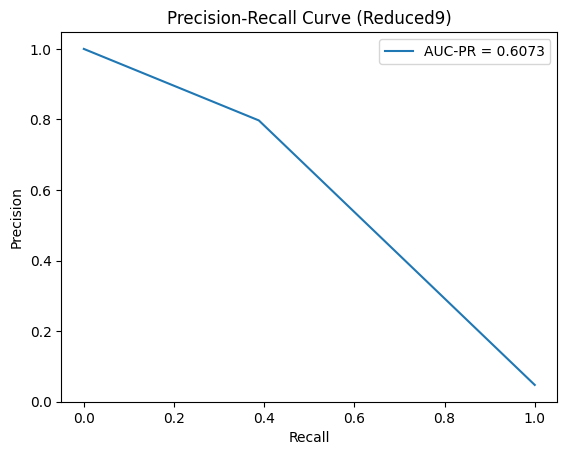

In [168]:
# AUC-PR
precision_reduced9, recall_reduced9, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced9)
auc_pr_reduced9 = auc(recall_reduced9, precision_reduced9)
print(f"AUC-PR (Reduced9): {auc_pr_reduced9:.4f}")

plt.plot(recall_reduced9, precision_reduced9, label=f'AUC-PR = {auc_pr_reduced9:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced9)')
plt.legend()
plt.show()

## 10. Reduced-10 - ETC, Bagging, LGBM

In [169]:
# Base models (Reduced10)
reduced10_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [170]:
# Meta-learner
meta_learner_reduced10 = LogisticRegression()

In [171]:
# Stacking Classifier
stacking_model_reduced10 = StackingClassifier(
    estimators=reduced10_models,
    final_estimator=meta_learner_reduced10,
    cv=5
)

In [172]:
# Train model
stacking_model_reduced10.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006028 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [173]:
# Predict
y_pred_stack_reduced10 = stacking_model_reduced10.predict(X_test_rfe)

In [174]:
# Evaluating the model
accuracy_stack_reduced10 = accuracy_score(y_test_rfe, y_pred_stack_reduced10)
conf_matrix_stack_reduced10 = confusion_matrix(y_test_rfe, y_pred_stack_reduced10)
class_report_stack_reduced10 = classification_report(y_test_rfe, y_pred_stack_reduced10)

TP = conf_matrix_stack_reduced10[1, 1]
FN = conf_matrix_stack_reduced10[1, 0]
FP = conf_matrix_stack_reduced10[0, 1]
TN = conf_matrix_stack_reduced10[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced10):")
print(f'Accuracy: {accuracy_stack_reduced10:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced10)

Evaluation Metrics (Reduced10):
Accuracy: 0.9669
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0046
Balanced Accuracy: 0.6951

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.89      0.70      0.76      3200
weighted avg       0.96      0.97      0.96      3200



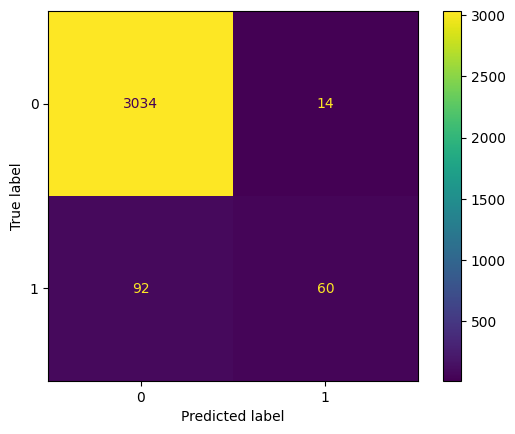

In [175]:
# Confusion matrix
conf_matrix_stack_reduced10 = confusion_matrix(y_test_rfe, y_pred_stack_reduced10)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced10, display_labels=stacking_model_reduced10.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced10): 0.6171


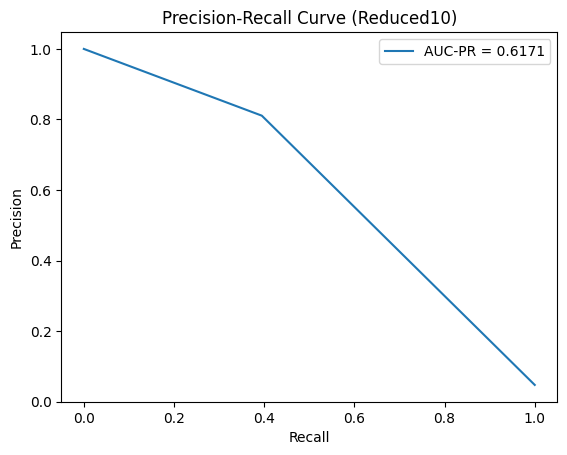

In [176]:
# AUC-PR
precision_reduced10, recall_reduced10, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced10)
auc_pr_reduced10 = auc(recall_reduced10, precision_reduced10)
print(f"AUC-PR (Reduced10): {auc_pr_reduced10:.4f}")

plt.plot(recall_reduced10, precision_reduced10, label=f'AUC-PR = {auc_pr_reduced10:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced10)')
plt.legend()
plt.show()

## 11. Reduced-11 - ETC, Bagging, NC

In [177]:
# Base models (Reduced11)
reduced11_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [178]:
# Meta-learner
meta_learner_reduced11 = LogisticRegression()

In [179]:
# Stacking Classifier
stacking_model_reduced11 = StackingClassifier(
    estimators=reduced11_models,
    final_estimator=meta_learner_reduced11,
    cv=5
)

In [180]:
# Train model
stacking_model_reduced11.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [181]:
# Predict
y_pred_stack_reduced11 = stacking_model_reduced11.predict(X_test_rfe)

In [182]:
# Evaluating the model
accuracy_stack_reduced11 = accuracy_score(y_test_rfe, y_pred_stack_reduced11)
conf_matrix_stack_reduced11 = confusion_matrix(y_test_rfe, y_pred_stack_reduced11)
class_report_stack_reduced11 = classification_report(y_test_rfe, y_pred_stack_reduced11)

TP = conf_matrix_stack_reduced11[1, 1]
FN = conf_matrix_stack_reduced11[1, 0]
FP = conf_matrix_stack_reduced11[0, 1]
TN = conf_matrix_stack_reduced11[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced11):")
print(f'Accuracy: {accuracy_stack_reduced11:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced11)

Evaluation Metrics (Reduced11):
Accuracy: 0.9656
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6850

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.38      0.51       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



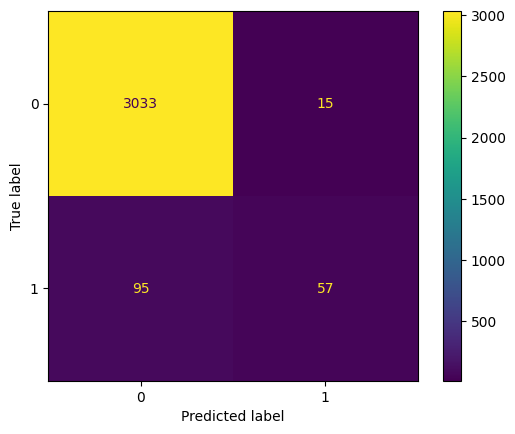

In [183]:
# Confusion matrix
conf_matrix_stack_reduced11 = confusion_matrix(y_test_rfe, y_pred_stack_reduced11)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced11, display_labels=stacking_model_reduced11.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced11): 0.5982


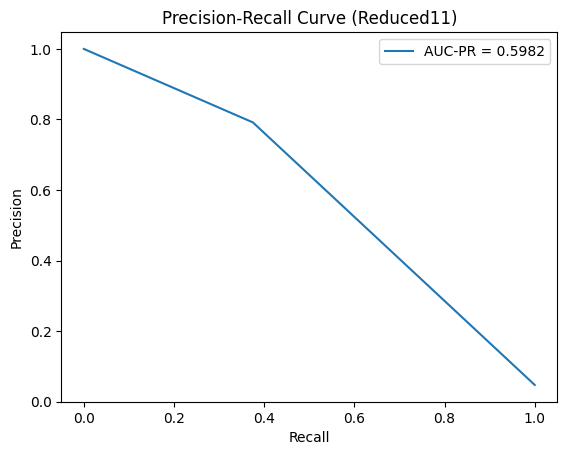

In [184]:
# AUC-PR
precision_reduced11, recall_reduced11, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced11)
auc_pr_reduced11 = auc(recall_reduced11, precision_reduced11)
print(f"AUC-PR (Reduced11): {auc_pr_reduced11:.4f}")

plt.plot(recall_reduced11, precision_reduced11, label=f'AUC-PR = {auc_pr_reduced11:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced11)')
plt.legend()
plt.show()

## 12. Reduced-12 - ETC, LGBM, NC

In [185]:
# Base models (Reduced12)
reduced12_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [186]:
# Meta-learner
meta_learner_reduced12 = LogisticRegression()

In [187]:
# Stacking Classifier
stacking_model_reduced12 = StackingClassifier(
    estimators=reduced12_models,
    final_estimator=meta_learner_reduced12,
    cv=5
)

In [188]:
# Train model
stacking_model_reduced12.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006910 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004425 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [189]:
# Predict
y_pred_stack_reduced12 = stacking_model_reduced12.predict(X_test_rfe)

In [190]:
# Evaluating the model
accuracy_stack_reduced12 = accuracy_score(y_test_rfe, y_pred_stack_reduced12)
conf_matrix_stack_reduced12 = confusion_matrix(y_test_rfe, y_pred_stack_reduced12)
class_report_stack_reduced12 = classification_report(y_test_rfe, y_pred_stack_reduced12)

TP = conf_matrix_stack_reduced12[1, 1]
FN = conf_matrix_stack_reduced12[1, 0]
FP = conf_matrix_stack_reduced12[0, 1]
TN = conf_matrix_stack_reduced12[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced12):")
print(f'Accuracy: {accuracy_stack_reduced12:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced12)

Evaluation Metrics (Reduced12):
Accuracy: 0.9653
True Positive Rate (TPR): 0.3684
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6817

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.37      0.50       152

    accuracy                           0.97      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.97      0.96      3200



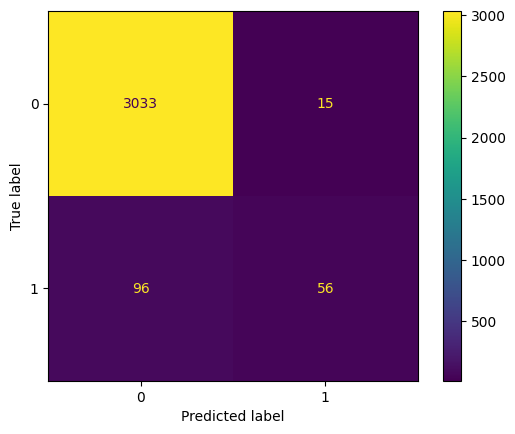

In [191]:
# Confusion matrix
conf_matrix_stack_reduced12 = confusion_matrix(y_test_rfe, y_pred_stack_reduced12)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced12, display_labels=stacking_model_reduced12.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced12): 0.5936


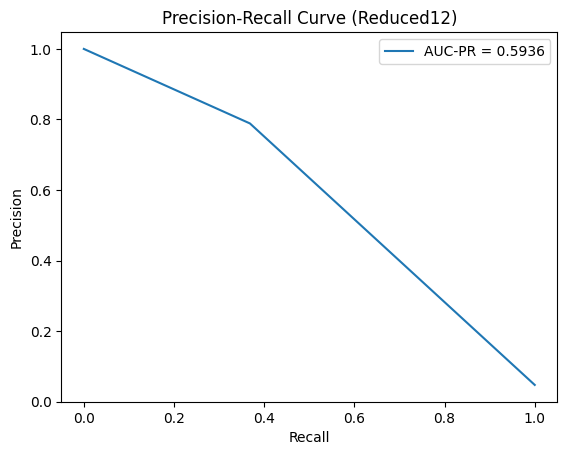

In [192]:
# AUC-PR
precision_reduced12, recall_reduced12, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced12)
auc_pr_reduced12 = auc(recall_reduced12, precision_reduced12)
print(f"AUC-PR (Reduced12): {auc_pr_reduced12:.4f}")

plt.plot(recall_reduced12, precision_reduced12, label=f'AUC-PR = {auc_pr_reduced12:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced12)')
plt.legend()
plt.show()

## 13. Reduced-13 - RF, Bagging, LGBM

In [193]:
# Base models (Reduced13)
reduced13_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [194]:
# Meta-learner
meta_learner_reduced13 = LogisticRegression()

In [195]:
# Stacking Classifier
stacking_model_reduced13 = StackingClassifier(
    estimators=reduced13_models,
    final_estimator=meta_learner_reduced13,
    cv=5
)

In [196]:
# Train model
stacking_model_reduced13.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003463 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [197]:
# Predict
y_pred_stack_reduced13 = stacking_model_reduced13.predict(X_test_rfe)

In [198]:
# Evaluating the model
accuracy_stack_reduced13 = accuracy_score(y_test_rfe, y_pred_stack_reduced13)
conf_matrix_stack_reduced13 = confusion_matrix(y_test_rfe, y_pred_stack_reduced13)
class_report_stack_reduced13 = classification_report(y_test_rfe, y_pred_stack_reduced13)

TP = conf_matrix_stack_reduced13[1, 1]
FN = conf_matrix_stack_reduced13[1, 0]
FP = conf_matrix_stack_reduced13[0, 1]
TN = conf_matrix_stack_reduced13[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced13):")
print(f'Accuracy: {accuracy_stack_reduced13:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced13)

Evaluation Metrics (Reduced13):
Accuracy: 0.9656
True Positive Rate (TPR): 0.3882
False Positive Rate (FPR): 0.0056
Balanced Accuracy: 0.6913

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.78      0.39      0.52       152

    accuracy                           0.97      3200
   macro avg       0.87      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



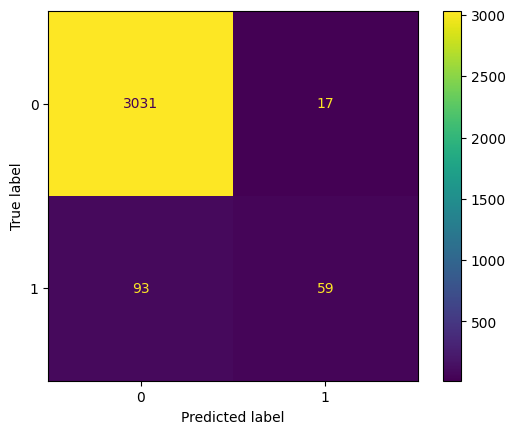

In [199]:
# Confusion matrix
conf_matrix_stack_reduced13 = confusion_matrix(y_test_rfe, y_pred_stack_reduced13)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced13, display_labels=stacking_model_reduced13.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced13): 0.5968


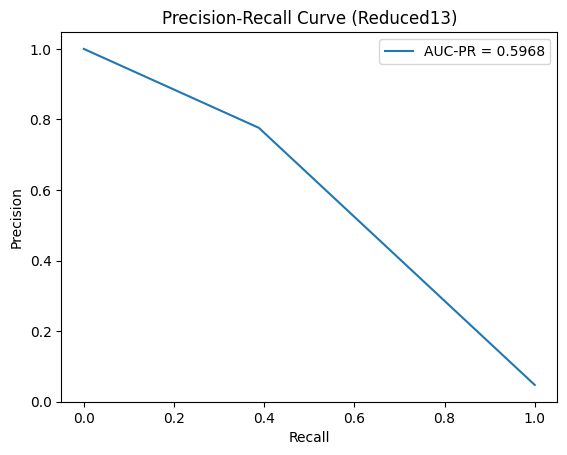

In [200]:
# AUC-PR
precision_reduced13, recall_reduced13, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced13)
auc_pr_reduced13 = auc(recall_reduced13, precision_reduced13)
print(f"AUC-PR (Reduced13): {auc_pr_reduced13:.4f}")

plt.plot(recall_reduced13, precision_reduced13, label=f'AUC-PR = {auc_pr_reduced13:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced13)')
plt.legend()
plt.show()

## 14. Reduced-14 - RF, Bagging, NC

In [201]:
# Base models (Reduced14)
reduced14_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [202]:
# Meta-learner
meta_learner_reduced14 = LogisticRegression()

In [203]:
# Stacking Classifier
stacking_model_reduced14 = StackingClassifier(
    estimators=reduced14_models,
    final_estimator=meta_learner_reduced14,
    cv=5
)

In [204]:
# Train model
stacking_model_reduced14.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [205]:
# Predict
y_pred_stack_reduced14 = stacking_model_reduced14.predict(X_test_rfe)

In [206]:
# Evaluating the model
accuracy_stack_reduced14 = accuracy_score(y_test_rfe, y_pred_stack_reduced14)
conf_matrix_stack_reduced14 = confusion_matrix(y_test_rfe, y_pred_stack_reduced14)
class_report_stack_reduced14 = classification_report(y_test_rfe, y_pred_stack_reduced14)

TP = conf_matrix_stack_reduced14[1, 1]
FN = conf_matrix_stack_reduced14[1, 0]
FP = conf_matrix_stack_reduced14[0, 1]
TN = conf_matrix_stack_reduced14[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced14):")
print(f'Accuracy: {accuracy_stack_reduced14:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced14)

Evaluation Metrics (Reduced14):
Accuracy: 0.9663
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.6947

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.79      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



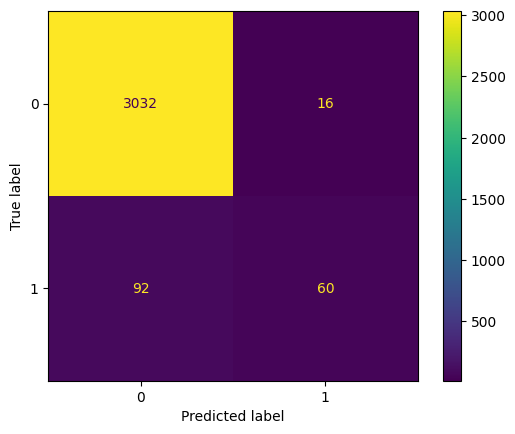

In [207]:
# Confusion matrix
conf_matrix_stack_reduced14 = confusion_matrix(y_test_rfe, y_pred_stack_reduced14)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced14, display_labels=stacking_model_reduced14.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced14): 0.6065


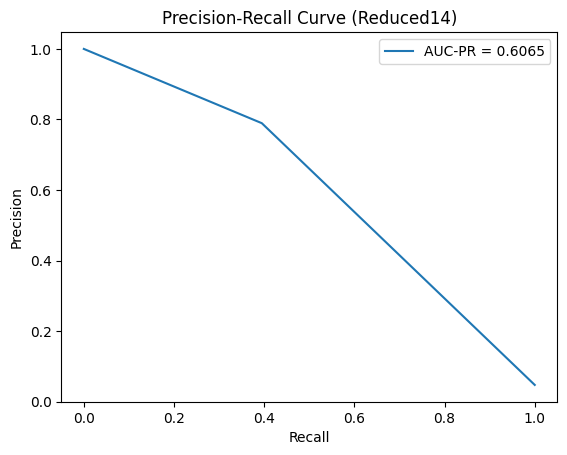

In [208]:
# AUC-PR
precision_reduced14, recall_reduced14, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced14)
auc_pr_reduced14 = auc(recall_reduced14, precision_reduced14)
print(f"AUC-PR (Reduced14): {auc_pr_reduced14:.4f}")

plt.plot(recall_reduced14, precision_reduced14, label=f'AUC-PR = {auc_pr_reduced14:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced14)')
plt.legend()
plt.show()

## 15. Reduced-15 - RF, LGBM, NC

In [209]:
# Base models (Reduced15)
reduced15_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [210]:
# Meta-learner
meta_learner_reduced15 = LogisticRegression()

In [211]:
# Stacking Classifier
stacking_model_reduced15 = StackingClassifier(
    estimators=reduced15_models,
    final_estimator=meta_learner_reduced15,
    cv=5
)

In [212]:
# Train model
stacking_model_reduced15.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004919 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [213]:
# Predict
y_pred_stack_reduced15 = stacking_model_reduced15.predict(X_test_rfe)

In [214]:
# Evaluating the model
accuracy_stack_reduced15 = accuracy_score(y_test_rfe, y_pred_stack_reduced15)
conf_matrix_stack_reduced15 = confusion_matrix(y_test_rfe, y_pred_stack_reduced15)
class_report_stack_reduced15 = classification_report(y_test_rfe, y_pred_stack_reduced15)

TP = conf_matrix_stack_reduced15[1, 1]
FN = conf_matrix_stack_reduced15[1, 0]
FP = conf_matrix_stack_reduced15[0, 1]
TN = conf_matrix_stack_reduced15[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced15):")
print(f'Accuracy: {accuracy_stack_reduced15:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced15)

Evaluation Metrics (Reduced15):
Accuracy: 0.9647
True Positive Rate (TPR): 0.3553
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6752

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.78      0.36      0.49       152

    accuracy                           0.96      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.96      0.96      3200



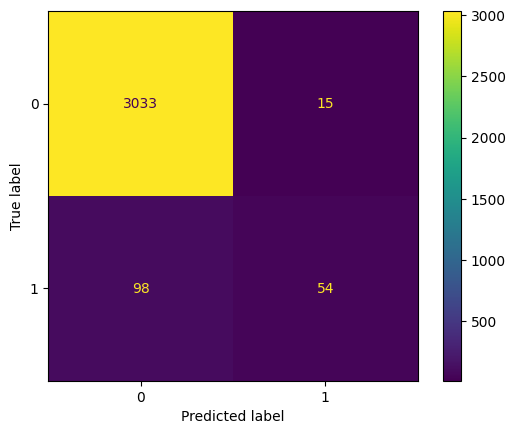

In [215]:
# Confusion matrix
conf_matrix_stack_reduced15 = confusion_matrix(y_test_rfe, y_pred_stack_reduced15)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced15, display_labels=stacking_model_reduced15.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced15): 0.5842


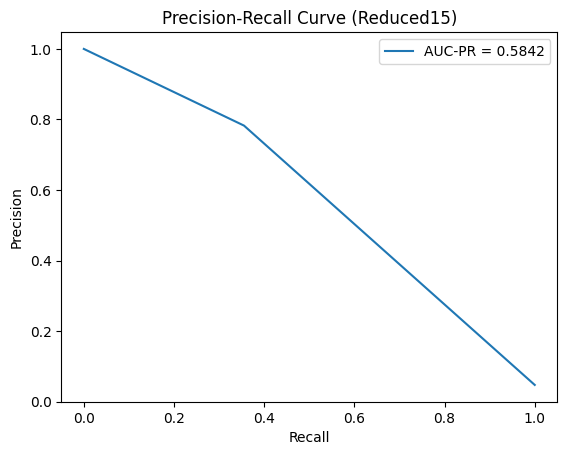

In [216]:
# AUC-PR
precision_reduced15, recall_reduced15, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced15)
auc_pr_reduced15 = auc(recall_reduced15, precision_reduced15)
print(f"AUC-PR (Reduced15): {auc_pr_reduced15:.4f}")

plt.plot(recall_reduced15, precision_reduced15, label=f'AUC-PR = {auc_pr_reduced15:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced15)')
plt.legend()
plt.show()

## 16. Reduced-16 - Bagging, LGBM, NC

In [217]:
# Base models (Reduced16)
reduced16_models = [
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [218]:
# Meta-learner
meta_learner_reduced16 = LogisticRegression()

In [219]:
# Stacking Classifier
stacking_model_reduced16 = StackingClassifier(
    estimators=reduced16_models,
    final_estimator=meta_learner_reduced16,
    cv=5
)

In [220]:
# Train model
stacking_model_reduced16.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [221]:
# Predict
y_pred_stack_reduced16 = stacking_model_reduced16.predict(X_test_rfe)

In [222]:
# Evaluating the model
accuracy_stack_reduced16 = accuracy_score(y_test_rfe, y_pred_stack_reduced16)
conf_matrix_stack_reduced16 = confusion_matrix(y_test_rfe, y_pred_stack_reduced16)
class_report_stack_reduced16 = classification_report(y_test_rfe, y_pred_stack_reduced16)

TP = conf_matrix_stack_reduced16[1, 1]
FN = conf_matrix_stack_reduced16[1, 0]
FP = conf_matrix_stack_reduced16[0, 1]
TN = conf_matrix_stack_reduced16[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced16):")
print(f'Accuracy: {accuracy_stack_reduced16:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced16)

Evaluation Metrics (Reduced16):
Accuracy: 0.9650
True Positive Rate (TPR): 0.3816
False Positive Rate (FPR): 0.0059
Balanced Accuracy: 0.6878

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.76      0.38      0.51       152

    accuracy                           0.96      3200
   macro avg       0.87      0.69      0.75      3200
weighted avg       0.96      0.96      0.96      3200



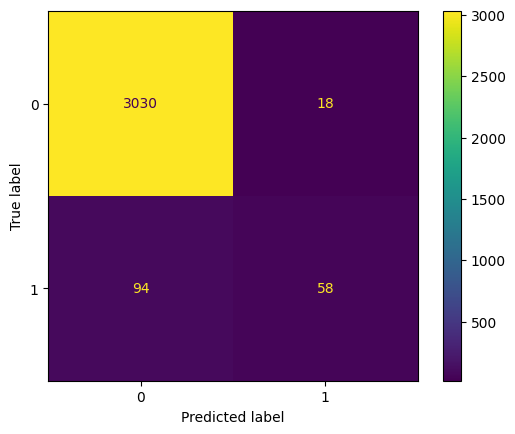

In [223]:
# Confusion matrix
conf_matrix_stack_reduced16 = confusion_matrix(y_test_rfe, y_pred_stack_reduced16)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced16, display_labels=stacking_model_reduced16.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced16): 0.5871


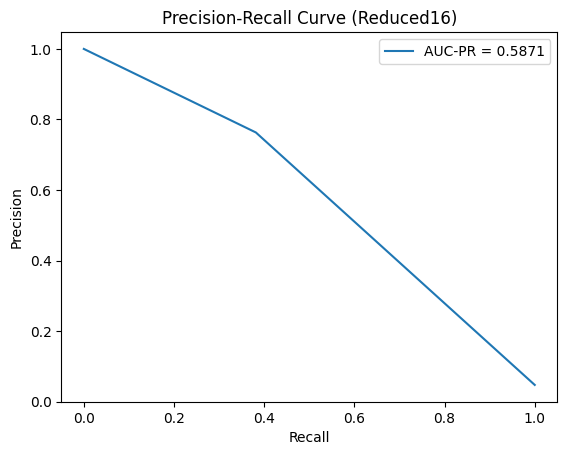

In [224]:
# AUC-PR
precision_reduced16, recall_reduced16, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced16)
auc_pr_reduced16 = auc(recall_reduced16, precision_reduced16)
print(f"AUC-PR (Reduced16): {auc_pr_reduced16:.4f}")

plt.plot(recall_reduced16, precision_reduced16, label=f'AUC-PR = {auc_pr_reduced16:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced16)')
plt.legend()
plt.show()

# Combinations of 2 Models:

## 17. Reduced-17 - ETC, RF

In [225]:
# Base models (Reduced17)
reduced17_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
]

In [226]:
# Meta-learner
meta_learner_reduced17 = LogisticRegression()

In [227]:
# Stacking Classifier
stacking_model_reduced17 = StackingClassifier(
    estimators=reduced17_models,
    final_estimator=meta_learner_reduced17,
    cv=5
)

In [228]:
# Train model
stacking_model_reduced17.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [229]:
# Predict
y_pred_stack_reduced17 = stacking_model_reduced17.predict(X_test_rfe)

In [230]:
# Evaluating the model
accuracy_stack_reduced17 = accuracy_score(y_test_rfe, y_pred_stack_reduced17)
conf_matrix_stack_reduced17 = confusion_matrix(y_test_rfe, y_pred_stack_reduced17)
class_report_stack_reduced17 = classification_report(y_test_rfe, y_pred_stack_reduced17)

TP = conf_matrix_stack_reduced17[1, 1]
FN = conf_matrix_stack_reduced17[1, 0]
FP = conf_matrix_stack_reduced17[0, 1]
TN = conf_matrix_stack_reduced17[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced17):")
print(f'Accuracy: {accuracy_stack_reduced17:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced17)

Evaluation Metrics (Reduced17):
Accuracy: 0.9659
True Positive Rate (TPR): 0.3816
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6883

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.38      0.52       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



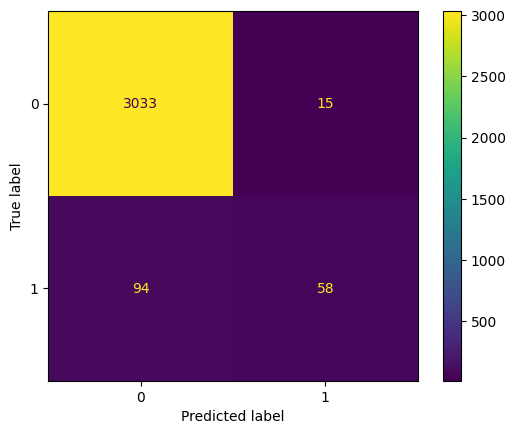

In [231]:
# Confusion matrix
conf_matrix_stack_reduced17 = confusion_matrix(y_test_rfe, y_pred_stack_reduced17)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced17, display_labels=stacking_model_reduced17.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced17): 0.6027


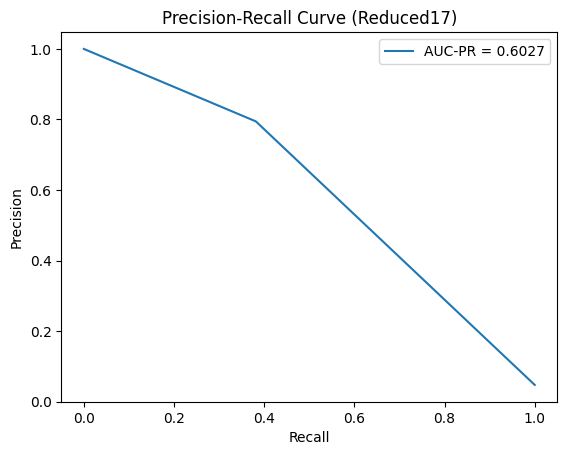

In [232]:
# AUC-PR
precision_reduced17, recall_reduced17, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced17)
auc_pr_reduced17 = auc(recall_reduced17, precision_reduced17)
print(f"AUC-PR (Reduced17): {auc_pr_reduced17:.4f}")

plt.plot(recall_reduced17, precision_reduced17, label=f'AUC-PR = {auc_pr_reduced17:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced17)')
plt.legend()
plt.show()

## 18. Reduced-18 - ETC, Bagging

In [233]:
# Base models (Reduced18)
reduced18_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42))
]

In [234]:
# Meta-learner
meta_learner_reduced18 = LogisticRegression()

In [235]:
# Stacking Classifier
stacking_model_reduced18 = StackingClassifier(
    estimators=reduced18_models,
    final_estimator=meta_learner_reduced18,
    cv=5
)

In [236]:
# Train model
stacking_model_reduced18.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [237]:
# Predict
y_pred_stack_reduced18 = stacking_model_reduced18.predict(X_test_rfe)

In [238]:
# Evaluating the model
accuracy_stack_reduced18 = accuracy_score(y_test_rfe, y_pred_stack_reduced18)
conf_matrix_stack_reduced18 = confusion_matrix(y_test_rfe, y_pred_stack_reduced18)
class_report_stack_reduced18 = classification_report(y_test_rfe, y_pred_stack_reduced18)

TP = conf_matrix_stack_reduced18[1, 1]
FN = conf_matrix_stack_reduced18[1, 0]
FP = conf_matrix_stack_reduced18[0, 1]
TN = conf_matrix_stack_reduced18[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced18):")
print(f'Accuracy: {accuracy_stack_reduced18:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced18)

Evaluation Metrics (Reduced18):
Accuracy: 0.9656
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6850

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.38      0.51       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



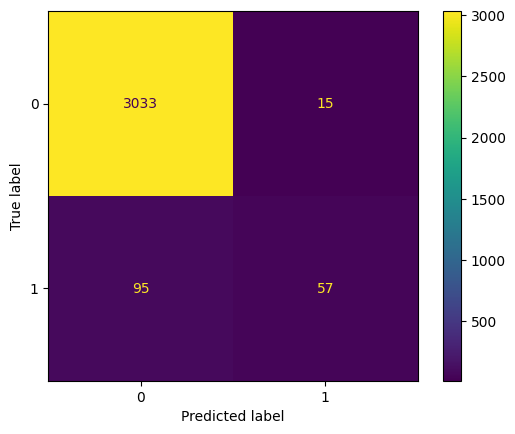

In [239]:
# Confusion matrix
conf_matrix_stack_reduced18 = confusion_matrix(y_test_rfe, y_pred_stack_reduced18)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced18, display_labels=stacking_model_reduced18.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced18): 0.5982


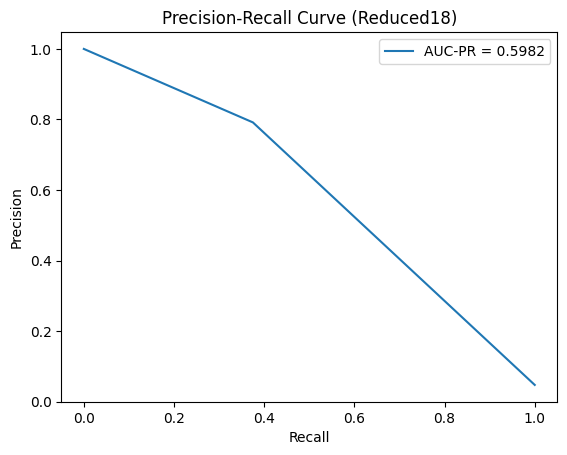

In [240]:
# AUC-PR
precision_reduced18, recall_reduced18, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced18)
auc_pr_reduced18 = auc(recall_reduced18, precision_reduced18)
print(f"AUC-PR (Reduced18): {auc_pr_reduced18:.4f}")

plt.plot(recall_reduced18, precision_reduced18, label=f'AUC-PR = {auc_pr_reduced18:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced18)')
plt.legend()
plt.show()

## 19. Reduced-19 - ETC, LGBM

In [241]:
# Base models (Reduced19)
reduced19_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [242]:
# Meta-learner
meta_learner_reduced19 = LogisticRegression()

In [243]:
# Stacking Classifier
stacking_model_reduced19 = StackingClassifier(
    estimators=reduced19_models,
    final_estimator=meta_learner_reduced19,
    cv=5
)

In [244]:
# Train model
stacking_model_reduced19.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005675 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [245]:
# Predict
y_pred_stack_reduced19 = stacking_model_reduced19.predict(X_test_rfe)

In [246]:
# Evaluating the model
accuracy_stack_reduced19 = accuracy_score(y_test_rfe, y_pred_stack_reduced19)
conf_matrix_stack_reduced19 = confusion_matrix(y_test_rfe, y_pred_stack_reduced19)
class_report_stack_reduced19 = classification_report(y_test_rfe, y_pred_stack_reduced19)

TP = conf_matrix_stack_reduced19[1, 1]
FN = conf_matrix_stack_reduced19[1, 0]
FP = conf_matrix_stack_reduced19[0, 1]
TN = conf_matrix_stack_reduced19[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced19):")
print(f'Accuracy: {accuracy_stack_reduced19:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced19)

Evaluation Metrics (Reduced19):
Accuracy: 0.9656
True Positive Rate (TPR): 0.3618
False Positive Rate (FPR): 0.0043
Balanced Accuracy: 0.6788

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.81      0.36      0.50       152

    accuracy                           0.97      3200
   macro avg       0.89      0.68      0.74      3200
weighted avg       0.96      0.97      0.96      3200



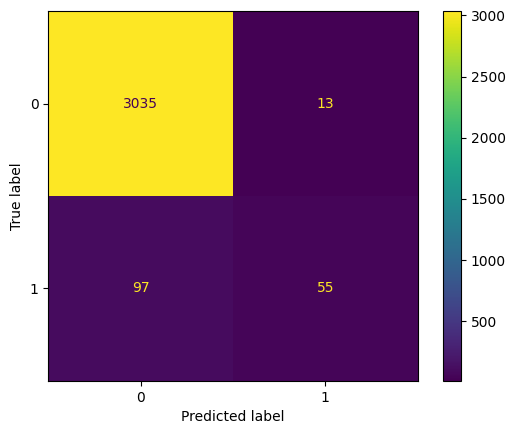

In [247]:
# Confusion matrix
conf_matrix_stack_reduced19 = confusion_matrix(y_test_rfe, y_pred_stack_reduced19)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced19, display_labels=stacking_model_reduced19.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced19): 0.6005


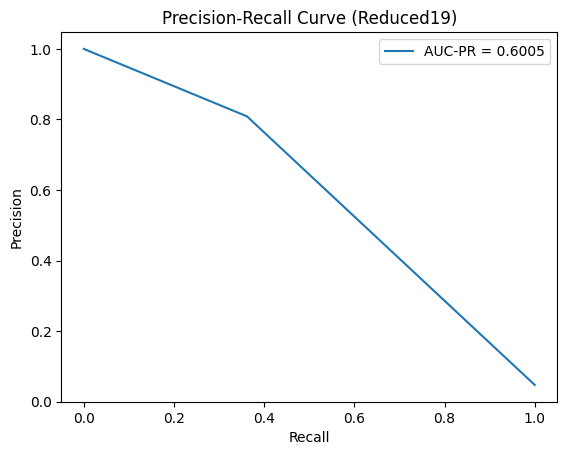

In [248]:
# AUC-PR
precision_reduced19, recall_reduced19, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced19)
auc_pr_reduced19 = auc(recall_reduced19, precision_reduced19)
print(f"AUC-PR (Reduced19): {auc_pr_reduced19:.4f}")

plt.plot(recall_reduced19, precision_reduced19, label=f'AUC-PR = {auc_pr_reduced19:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced19)')
plt.legend()
plt.show()

## 20. Reduced-20 - ETC, NC

In [249]:
# Base models (Reduced20)
reduced20_models = [
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('nc', NearestCentroid())
]

In [250]:
# Meta-learner
meta_learner_reduced20 = LogisticRegression()

In [251]:
# Stacking Classifier
stacking_model_reduced20 = StackingClassifier(
    estimators=reduced20_models,
    final_estimator=meta_learner_reduced20,
    cv=5
)

In [252]:
# Train model
stacking_model_reduced20.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('etc', ExtraTreesClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [253]:
# Predict
y_pred_stack_reduced20 = stacking_model_reduced20.predict(X_test_rfe)

In [254]:
# Evaluating the model
accuracy_stack_reduced20 = accuracy_score(y_test_rfe, y_pred_stack_reduced20)
conf_matrix_stack_reduced20 = confusion_matrix(y_test_rfe, y_pred_stack_reduced20)
class_report_stack_reduced20 = classification_report(y_test_rfe, y_pred_stack_reduced20)

TP = conf_matrix_stack_reduced20[1, 1]
FN = conf_matrix_stack_reduced20[1, 0]
FP = conf_matrix_stack_reduced20[0, 1]
TN = conf_matrix_stack_reduced20[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced20):")
print(f'Accuracy: {accuracy_stack_reduced20:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced20)

Evaluation Metrics (Reduced20):
Accuracy: 0.9656
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6850

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.38      0.51       152

    accuracy                           0.97      3200
   macro avg       0.88      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



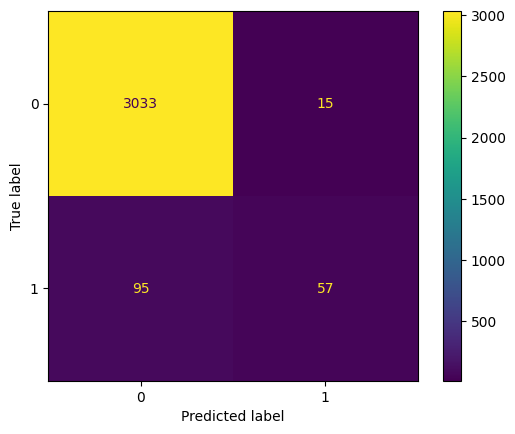

In [255]:
# Confusion matrix
conf_matrix_stack_reduced20 = confusion_matrix(y_test_rfe, y_pred_stack_reduced20)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced20, display_labels=stacking_model_reduced20.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced20): 0.5982


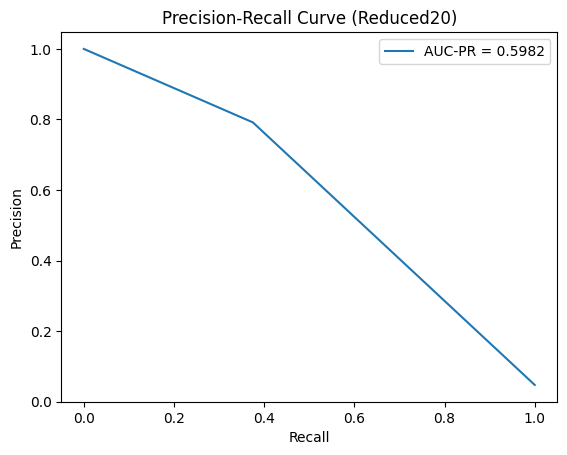

In [256]:
# AUC-PR
precision_reduced20, recall_reduced20, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced20)
auc_pr_reduced20 = auc(recall_reduced20, precision_reduced20)
print(f"AUC-PR (Reduced20): {auc_pr_reduced20:.4f}")

plt.plot(recall_reduced20, precision_reduced20, label=f'AUC-PR = {auc_pr_reduced20:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced20)')
plt.legend()
plt.show()

## 21. Reduced-21 - RF, Bagging

In [257]:
# Base models (Reduced21)
reduced21_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('bagging', BaggingClassifier(random_state=42))
]

In [258]:
# Meta-learner
meta_learner_reduced21 = LogisticRegression()

In [259]:
# Stacking Classifier
stacking_model_reduced21 = StackingClassifier(
    estimators=reduced21_models,
    final_estimator=meta_learner_reduced21,
    cv=5
)

In [260]:
# Train model
stacking_model_reduced21.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('bagging', BaggingClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [261]:
# Predict
y_pred_stack_reduced21 = stacking_model_reduced21.predict(X_test_rfe)

In [262]:
# Evaluating the model
accuracy_stack_reduced21 = accuracy_score(y_test_rfe, y_pred_stack_reduced21)
conf_matrix_stack_reduced21 = confusion_matrix(y_test_rfe, y_pred_stack_reduced21)
class_report_stack_reduced21 = classification_report(y_test_rfe, y_pred_stack_reduced21)

TP = conf_matrix_stack_reduced21[1, 1]
FN = conf_matrix_stack_reduced21[1, 0]
FP = conf_matrix_stack_reduced21[0, 1]
TN = conf_matrix_stack_reduced21[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced21):")
print(f'Accuracy: {accuracy_stack_reduced21:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced21)

Evaluation Metrics (Reduced21):
Accuracy: 0.9666
True Positive Rate (TPR): 0.3947
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6949

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.39      0.53       152

    accuracy                           0.97      3200
   macro avg       0.89      0.69      0.76      3200
weighted avg       0.96      0.97      0.96      3200



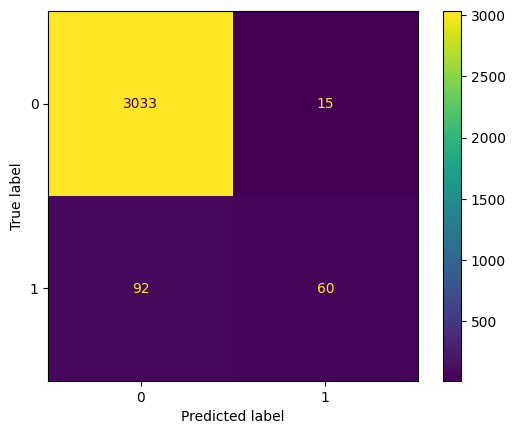

In [263]:
# Confusion matrix
conf_matrix_stack_reduced21 = confusion_matrix(y_test_rfe, y_pred_stack_reduced21)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced21, display_labels=stacking_model_reduced21.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced21): 0.6117


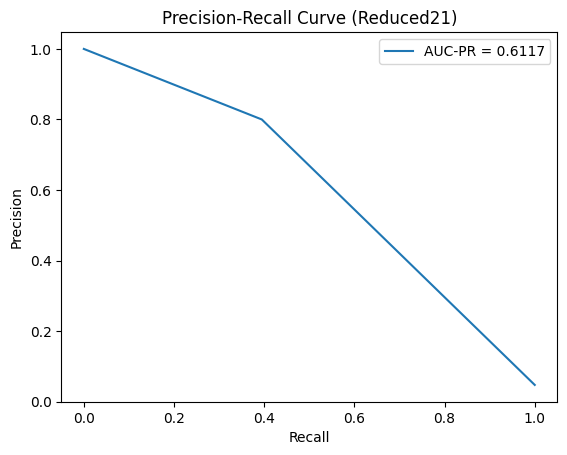

In [264]:
# AUC-PR
precision_reduced21, recall_reduced21, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced21)
auc_pr_reduced21 = auc(recall_reduced21, precision_reduced21)
print(f"AUC-PR (Reduced21): {auc_pr_reduced21:.4f}")

plt.plot(recall_reduced21, precision_reduced21, label=f'AUC-PR = {auc_pr_reduced21:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced21)')
plt.legend()
plt.show()

## 22. Reduced-22 - RF, LGBM

In [265]:
# Base models (Reduced22)
reduced22_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [266]:
# Meta-learner
meta_learner_reduced22 = LogisticRegression()

In [267]:
# Stacking Classifier
stacking_model_reduced22 = StackingClassifier(
    estimators=reduced22_models,
    final_estimator=meta_learner_reduced22,
    cv=5
)

In [268]:
# Train model
stacking_model_reduced22.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004243 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [269]:
# Predict
y_pred_stack_reduced22 = stacking_model_reduced22.predict(X_test_rfe)

In [270]:
# Evaluating the model
accuracy_stack_reduced22 = accuracy_score(y_test_rfe, y_pred_stack_reduced22)
conf_matrix_stack_reduced22 = confusion_matrix(y_test_rfe, y_pred_stack_reduced22)
class_report_stack_reduced22 = classification_report(y_test_rfe, y_pred_stack_reduced22)

TP = conf_matrix_stack_reduced22[1, 1]
FN = conf_matrix_stack_reduced22[1, 0]
FP = conf_matrix_stack_reduced22[0, 1]
TN = conf_matrix_stack_reduced22[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced22):")
print(f'Accuracy: {accuracy_stack_reduced22:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced22)

Evaluation Metrics (Reduced22):
Accuracy: 0.9653
True Positive Rate (TPR): 0.3684
False Positive Rate (FPR): 0.0049
Balanced Accuracy: 0.6817

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.37      0.50       152

    accuracy                           0.97      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.97      0.96      3200



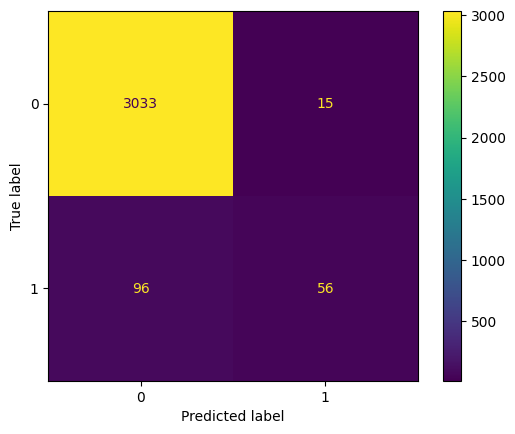

In [271]:
# Confusion matrix
conf_matrix_stack_reduced22 = confusion_matrix(y_test_rfe, y_pred_stack_reduced22)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced22, display_labels=stacking_model_reduced22.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced22): 0.5936


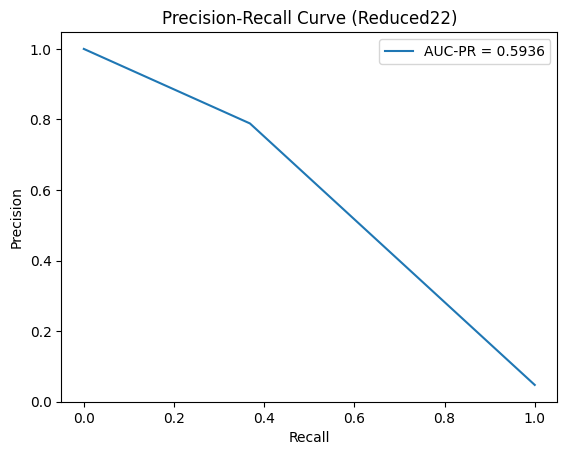

In [272]:
# AUC-PR
precision_reduced22, recall_reduced22, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced22)
auc_pr_reduced22 = auc(recall_reduced22, precision_reduced22)
print(f"AUC-PR (Reduced22): {auc_pr_reduced22:.4f}")

plt.plot(recall_reduced22, precision_reduced22, label=f'AUC-PR = {auc_pr_reduced22:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced22)')
plt.legend()
plt.show()

## 23. Reduced-23 - RF, NC

In [273]:
# Base models (Reduced23)
reduced23_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('nc', NearestCentroid())
]

In [274]:
# Meta-learner
meta_learner_reduced23 = LogisticRegression()

In [275]:
# Stacking Classifier
stacking_model_reduced23 = StackingClassifier(
    estimators=reduced23_models,
    final_estimator=meta_learner_reduced23,
    cv=5
)

In [276]:
# Train model
stacking_model_reduced23.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [277]:
# Predict
y_pred_stack_reduced23 = stacking_model_reduced23.predict(X_test_rfe)

In [278]:
# Evaluating the model
accuracy_stack_reduced23 = accuracy_score(y_test_rfe, y_pred_stack_reduced23)
conf_matrix_stack_reduced23 = confusion_matrix(y_test_rfe, y_pred_stack_reduced23)
class_report_stack_reduced23 = classification_report(y_test_rfe, y_pred_stack_reduced23)

TP = conf_matrix_stack_reduced23[1, 1]
FN = conf_matrix_stack_reduced23[1, 0]
FP = conf_matrix_stack_reduced23[0, 1]
TN = conf_matrix_stack_reduced23[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced23):")
print(f'Accuracy: {accuracy_stack_reduced23:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced23)

Evaluation Metrics (Reduced23):
Accuracy: 0.9669
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0036
Balanced Accuracy: 0.6857

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.84      0.38      0.52       152

    accuracy                           0.97      3200
   macro avg       0.90      0.69      0.75      3200
weighted avg       0.96      0.97      0.96      3200



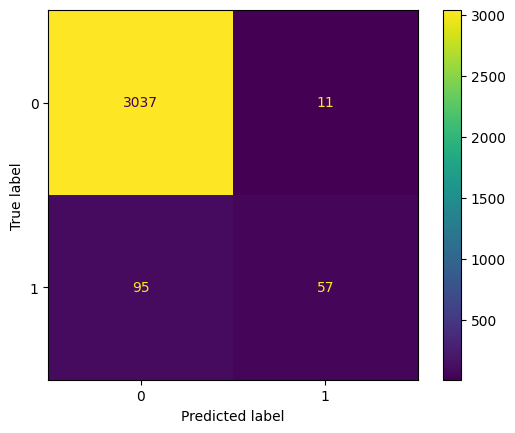

In [279]:
# Confusion matrix
conf_matrix_stack_reduced23 = confusion_matrix(y_test_rfe, y_pred_stack_reduced23)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced23, display_labels=stacking_model_reduced23.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced23): 0.6215


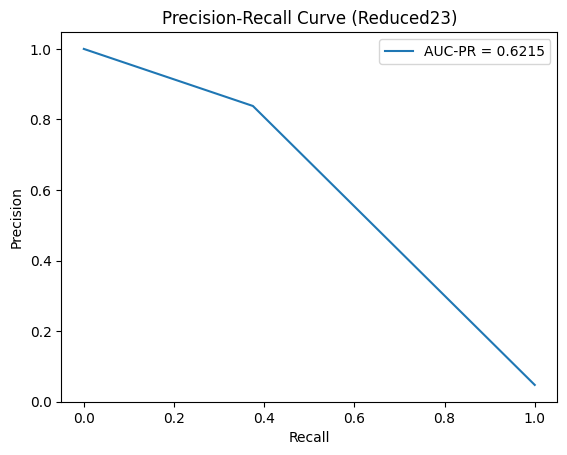

In [280]:
precision_reduced23, recall_reduced23, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced23)
auc_pr_reduced23 = auc(recall_reduced23, precision_reduced23)
print(f"AUC-PR (Reduced23): {auc_pr_reduced23:.4f}")

plt.plot(recall_reduced23, precision_reduced23, label=f'AUC-PR = {auc_pr_reduced23:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced23)')
plt.legend()
plt.show()

## 24. Reduced-24 - Bagging, LGBM

In [281]:
# Base models (Reduced24)
reduced24_models = [
    ('bagging', BaggingClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42))
]

In [282]:
# Meta-learner
meta_learner_reduced24 = LogisticRegression()

In [283]:
# Stacking Classifier
stacking_model_reduced24 = StackingClassifier(
    estimators=reduced24_models,
    final_estimator=meta_learner_reduced24,
    cv=5
)

In [284]:
# Train model
stacking_model_reduced24.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003924 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('bagging', BaggingClassifier(random_state=42)),
                               ('lgbm', LGBMClassifier(random_state=42))],
                   final_estimator=LogisticRegression())

In [285]:
# Predict
y_pred_stack_reduced24 = stacking_model_reduced24.predict(X_test_rfe)

In [286]:
# Evaluating the model
accuracy_stack_reduced24 = accuracy_score(y_test_rfe, y_pred_stack_reduced24)
conf_matrix_stack_reduced24 = confusion_matrix(y_test_rfe, y_pred_stack_reduced24)
class_report_stack_reduced24 = classification_report(y_test_rfe, y_pred_stack_reduced24)

TP = conf_matrix_stack_reduced24[1, 1]
FN = conf_matrix_stack_reduced24[1, 0]
FP = conf_matrix_stack_reduced24[0, 1]
TN = conf_matrix_stack_reduced24[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced24):")
print(f'Accuracy: {accuracy_stack_reduced24:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced24)

Evaluation Metrics (Reduced24):
Accuracy: 0.9653
True Positive Rate (TPR): 0.3750
False Positive Rate (FPR): 0.0052
Balanced Accuracy: 0.6849

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.78      0.38      0.51       152

    accuracy                           0.97      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.97      0.96      3200



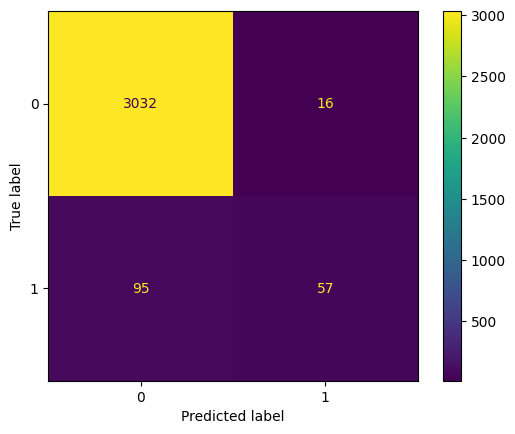

In [287]:
# Confusion matrix
conf_matrix_stack_reduced24 = confusion_matrix(y_test_rfe, y_pred_stack_reduced24)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced24, display_labels=stacking_model_reduced24.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced24): 0.5928


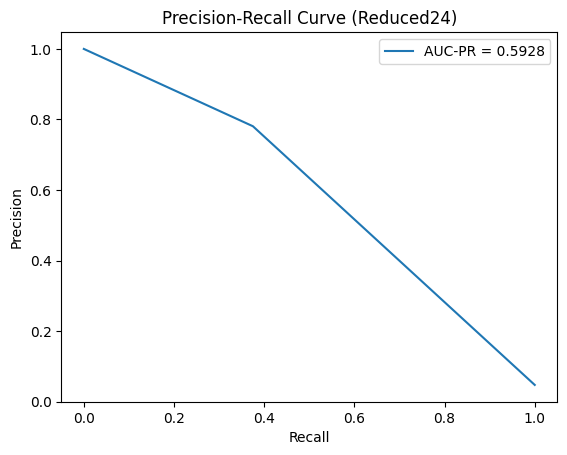

In [288]:
# AUC-PR
precision_reduced24, recall_reduced24, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced24)
auc_pr_reduced24 = auc(recall_reduced24, precision_reduced24)
print(f"AUC-PR (Reduced24): {auc_pr_reduced24:.4f}")

plt.plot(recall_reduced24, precision_reduced24, label=f'AUC-PR = {auc_pr_reduced24:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced24)')
plt.legend()
plt.show()

## 25. Reduced-25 - Bagging, NC

In [289]:
# Base models (Reduced25)
reduced25_models = [
    ('bagging', BaggingClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [290]:
# Meta-learner
meta_learner_reduced25 = LogisticRegression()

In [291]:
# Stacking Classifier
stacking_model_reduced25 = StackingClassifier(
    estimators=reduced25_models,
    final_estimator=meta_learner_reduced25,
    cv=5
)

In [292]:
# Train model
stacking_model_reduced25.fit(X_train_rfe, y_train_rfe)

StackingClassifier(cv=5,
                   estimators=[('bagging', BaggingClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [293]:
# Predict
y_pred_stack_reduced25 = stacking_model_reduced25.predict(X_test_rfe)

In [294]:
# Evaluating the model
accuracy_stack_reduced25 = accuracy_score(y_test_rfe, y_pred_stack_reduced25)
conf_matrix_stack_reduced25 = confusion_matrix(y_test_rfe, y_pred_stack_reduced25)
class_report_stack_reduced25 = classification_report(y_test_rfe, y_pred_stack_reduced25)

TP = conf_matrix_stack_reduced25[1, 1]
FN = conf_matrix_stack_reduced25[1, 0]
FP = conf_matrix_stack_reduced25[0, 1]
TN = conf_matrix_stack_reduced25[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced25):")
print(f'Accuracy: {accuracy_stack_reduced25:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced25)

Evaluation Metrics (Reduced25):
Accuracy: 0.9628
True Positive Rate (TPR): 0.3421
False Positive Rate (FPR): 0.0062
Balanced Accuracy: 0.6679

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.73      0.34      0.47       152

    accuracy                           0.96      3200
   macro avg       0.85      0.67      0.72      3200
weighted avg       0.96      0.96      0.96      3200



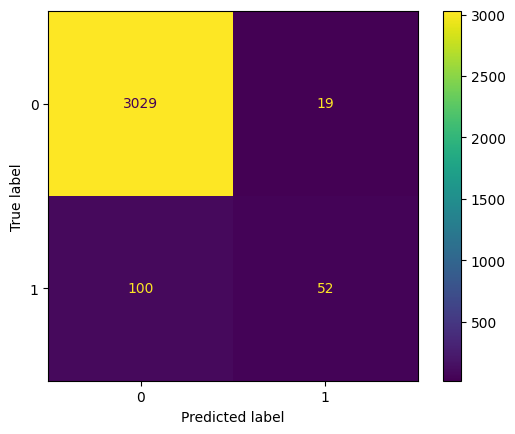

In [295]:
# Confusion matrix
conf_matrix_stack_reduced25 = confusion_matrix(y_test_rfe, y_pred_stack_reduced25)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced25, display_labels=stacking_model_reduced25.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced25): 0.5529


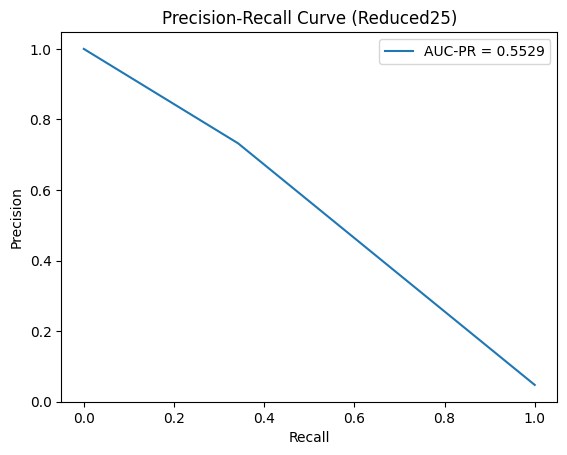

In [296]:
# AUC-PR
precision_reduced25, recall_reduced25, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced25)
auc_pr_reduced25 = auc(recall_reduced25, precision_reduced25)
print(f"AUC-PR (Reduced25): {auc_pr_reduced25:.4f}")

plt.plot(recall_reduced25, precision_reduced25, label=f'AUC-PR = {auc_pr_reduced25:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced25)')
plt.legend()
plt.show()

## 26. LGBM, NC - LGBM, NC

In [297]:
# Base models (Reduced26)
reduced26_models = [
    ('lgbm', LGBMClassifier(random_state=42)),
    ('nc', NearestCentroid())
]

In [298]:
# Meta-learner
meta_learner_reduced26 = LogisticRegression()

In [299]:
# Stacking Classifier
stacking_model_reduced26 = StackingClassifier(
    estimators=reduced26_models,
    final_estimator=meta_learner_reduced26,
    cv=5
)

In [300]:
# Train model
stacking_model_reduced26.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795
[LightGBM] [Info] Number of positive: 513, number of negative: 9727
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3807
[LightGBM] [Info] Number of data points in the train set: 10240, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050098 -> initscore=-2.942385
[LightGBM] [Info] Start training from score -2.942385
[LightGBM] [Info]

StackingClassifier(cv=5,
                   estimators=[('lgbm', LGBMClassifier(random_state=42)),
                               ('nc', NearestCentroid())],
                   final_estimator=LogisticRegression())

In [301]:
# Predict
y_pred_stack_reduced26 = stacking_model_reduced26.predict(X_test_rfe)

In [302]:
# Evaluating the model
accuracy_stack_reduced26 = accuracy_score(y_test_rfe, y_pred_stack_reduced26)
conf_matrix_stack_reduced26 = confusion_matrix(y_test_rfe, y_pred_stack_reduced26)
class_report_stack_reduced26 = classification_report(y_test_rfe, y_pred_stack_reduced26)

TP = conf_matrix_stack_reduced26[1, 1]
FN = conf_matrix_stack_reduced26[1, 0]
FP = conf_matrix_stack_reduced26[0, 1]
TN = conf_matrix_stack_reduced26[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print("Evaluation Metrics (Reduced26):")
print(f'Accuracy: {accuracy_stack_reduced26:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_stack_reduced26)

Evaluation Metrics (Reduced26):
Accuracy: 0.9634
True Positive Rate (TPR): 0.3618
False Positive Rate (FPR): 0.0066
Balanced Accuracy: 0.6776

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.73      0.36      0.48       152

    accuracy                           0.96      3200
   macro avg       0.85      0.68      0.73      3200
weighted avg       0.96      0.96      0.96      3200



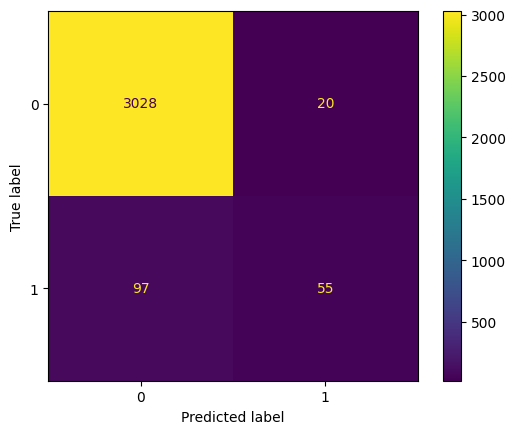

In [303]:
# Confusion matrix
conf_matrix_stack_reduced26 = confusion_matrix(y_test_rfe, y_pred_stack_reduced26)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack_reduced26, display_labels=stacking_model_reduced26.classes_)
disp.plot()
plt.show()

AUC-PR (Reduced26): 0.5627


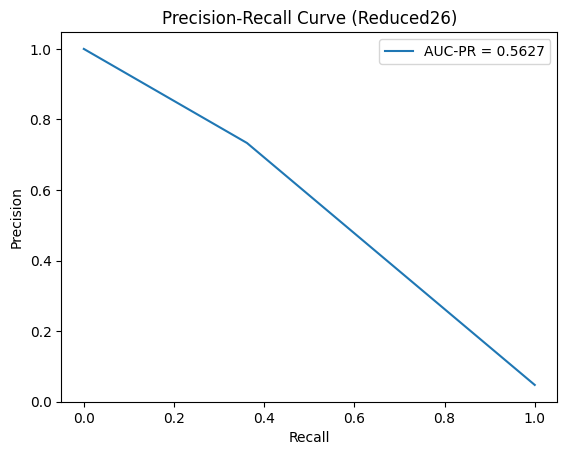

In [304]:
# AUC-PR
precision_reduced26, recall_reduced26, _ = precision_recall_curve(y_test_rfe, y_pred_stack_reduced26)
auc_pr_reduced26 = auc(recall_reduced26, precision_reduced26)
print(f"AUC-PR (Reduced26): {auc_pr_reduced26:.4f}")

plt.plot(recall_reduced26, precision_reduced26, label=f'AUC-PR = {auc_pr_reduced26:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Reduced26)')
plt.legend()
plt.show()

# Voting Ensemble Model

In [305]:
from sklearn.ensemble import VotingClassifier

In [306]:
# Voting Classifier (Soft Voting)
voting_model = VotingClassifier(estimators=base_models, voting='hard')

In [307]:
# Train Model
voting_model.fit(X_train_rfe, y_train_rfe)

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007164 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3824
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


VotingClassifier(estimators=[('nc', NearestCentroid()),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('lda', LinearDiscriminantAnalysis()),
                             ('bagging', BaggingClassifier(random_state=42)),
                             ('perceptron', Perceptron(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_by...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('lgbm', LGBMClassifier(random_state=42)),
                             ('bnb', BernoulliNB()),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('sgd',
                              SGDClassifier(loss='log_loss', random_state=42)),
                             ('etc', ExtraTreesClassifier(random_state=42))])

In [308]:
# Make predictions
y_pred_vote = voting_model.predict(X_test_rfe)

In [309]:
# Evaluate model
accuracy_vote = accuracy_score(y_test_rfe, y_pred_vote)
conf_matrix_vote = confusion_matrix(y_test_rfe, y_pred_vote)
class_report_vote = classification_report(y_test_rfe, y_pred_vote)

TP = conf_matrix_vote[1, 1]
FN = conf_matrix_vote[1, 0]
FP = conf_matrix_vote[0, 1]
TN = conf_matrix_vote[0, 0]

TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
balanced_accuracy = (TPR + (TN / (TN + FP))) / 2 if (TN + FP) > 0 else 0

print(f'Voting Ensemble Accuracy: {accuracy_vote:.4f}')
print(f'True Positive Rate (TPR): {TPR:.4f}')
print(f'False Positive Rate (FPR): {FPR:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy:.4f}')
print('\nClassification Report:')
print(class_report_vote)

Voting Ensemble Accuracy: 0.9656
True Positive Rate (TPR): 0.3684
False Positive Rate (FPR): 0.0046
Balanced Accuracy: 0.6819

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.80      0.37      0.50       152

    accuracy                           0.97      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.97      0.96      3200



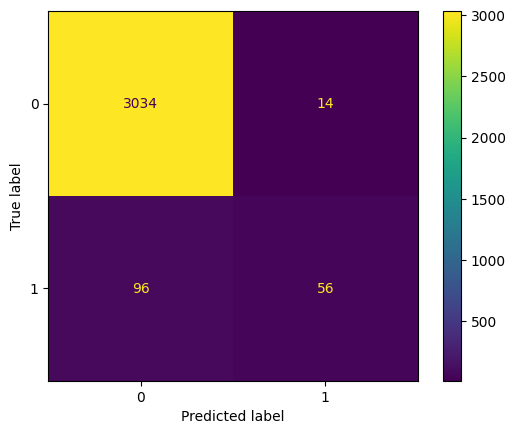

In [310]:
# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_vote, display_labels=voting_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5992


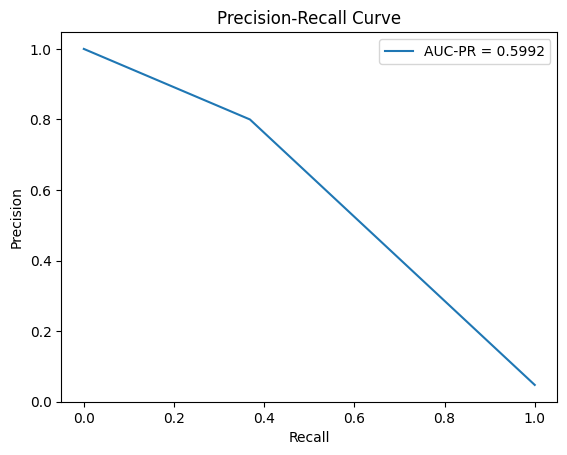

In [311]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test_rfe, y_pred_vote)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Precision-Recall Curves for All Models

In [312]:
# Model predictions
model_preds = {
    # Base Models
    'LDA': y_pred_LDA,                        
    'XGB': y_pred_XGB,                         
    'NC': y_pred_NC,                           
    'SGD': y_pred_SGD,                         
    'ET': y_pred_ET,                                                  
    'Perceptron': y_pred_PRC,                  
    'BNB': y_pred_BNB,                        
    'DT': y_pred_DT,                           
    'Bagging': y_pred_BAG,                     
    'LGBM': y_pred_LGBM,                       

    # Ensemble Models
    'Stacking Full': y_pred_stack,
    'Stacking R1': stacking_model_reduced1.predict(X_test_rfe),
    'Stacking R2': stacking_model_reduced2.predict(X_test_rfe),
    'Stacking R3': stacking_model_reduced3.predict(X_test_rfe),
    'Stacking R4': stacking_model_reduced4.predict(X_test_rfe),
    'Stacking R5': stacking_model_reduced5.predict(X_test_rfe),
    'Stacking R6': stacking_model_reduced6.predict(X_test_rfe),
    'Stacking R7': stacking_model_reduced7.predict(X_test_rfe),
    'Stacking R8': stacking_model_reduced8.predict(X_test_rfe),
    'Stacking R9': stacking_model_reduced9.predict(X_test_rfe),
    'Stacking R10': stacking_model_reduced10.predict(X_test_rfe),
    'Stacking R11': stacking_model_reduced11.predict(X_test_rfe),
    'Stacking R12': stacking_model_reduced12.predict(X_test_rfe),
    'Stacking R13': stacking_model_reduced13.predict(X_test_rfe),
    'Stacking R14': stacking_model_reduced14.predict(X_test_rfe),
    'Stacking R15': stacking_model_reduced15.predict(X_test_rfe),
    'Stacking R16': stacking_model_reduced16.predict(X_test_rfe),
    'Stacking R17': stacking_model_reduced17.predict(X_test_rfe),
    'Stacking R18': stacking_model_reduced18.predict(X_test_rfe),
    'Stacking R19': stacking_model_reduced19.predict(X_test_rfe),
    'Stacking R20': stacking_model_reduced20.predict(X_test_rfe),
    'Stacking R21': stacking_model_reduced21.predict(X_test_rfe),
    'Stacking R22': stacking_model_reduced22.predict(X_test_rfe),
    'Stacking R23': stacking_model_reduced23.predict(X_test_rfe),
    'Stacking R24': stacking_model_reduced24.predict(X_test_rfe),
    'Stacking R25': stacking_model_reduced25.predict(X_test_rfe),
    'Stacking R26': stacking_model_reduced26.predict(X_test_rfe),
}

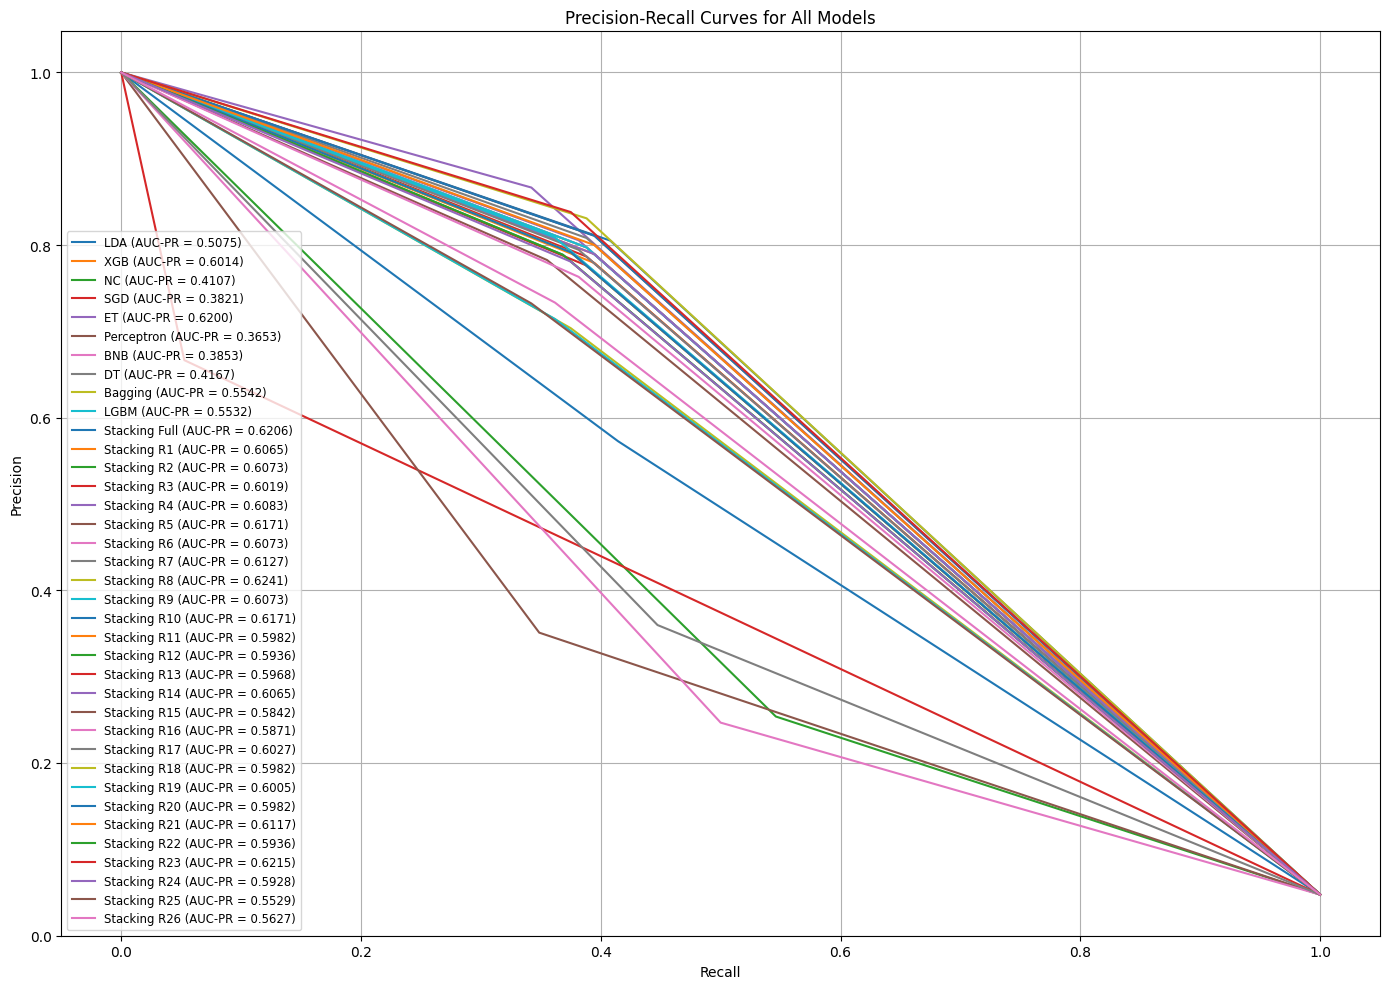

In [313]:
# Plot PR Curves
plt.figure(figsize=(14, 10))
for name, preds in model_preds.items():
    precision, recall, _ = precision_recall_curve(y_test_rfe, preds)
    auc_pr = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC-PR = {auc_pr:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for All Models')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()